In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from scipy.integrate import solve_ivp

**Background**:

When a star of mass $m_{\star}$ and radius $R_{\star}$ passes within the tidal radius

$$
\begin{equation*}
R_T \approx R_{\star}\left(\frac{M_{\bullet}}{m_{\star}}\right)^{1 / 3}
\end{equation*}
$$

of a black hole of mass $M_{\bullet}$, tidal forces exceed the star's self-gravity and the star is disrupted. The bound fraction of the debris returns to pericentre at a rate $\dot{M}(t)$ that at late times follows the well-known power law $\dot{M} \propto t^{-5 / 3}$. The goal of this exercise is to derive and test this scaling numerically, starting from the orbital dynamics, and to explore how general-relativistic corrections modify it.

**Step 1 - Stellar centre-of-mass orbit**:

Integrate the equation of motion for the stellar centre of mass:

$$
\begin{equation*}
\ddot{\mathbf{r}}=-\frac{G M_{\bullet}}{r^3} \mathbf{r}+\mathbf{a}_{\mathrm{PN}}(\mathbf{r}, \dot{\mathbf{r}}),
\end{equation*}
$$

where $\mathbf{a}_{\mathrm{PN}}$ is the leading-order post-Newtonian correction (1PN, $q \rightarrow 0$ limit):

$$
\begin{equation*}
\mathbf{a}_{\mathrm{PN}}=\frac{G M_{\bullet}}{c^2 r^3}\left[\left(4 \frac{G M_{\bullet}}{r}-v^2\right) \mathbf{r}+4(\mathbf{r} \cdot \dot{\mathbf{r}}) \dot{\mathbf{r}}\right] .
\end{equation*}
$$

Set $\mathbf{a}_{\mathrm{PN}}=\mathbf{0}$ to recover the Newtonian case. Use initial conditions corresponding to a parabolic orbit ( $E_{\mathrm{cm}}=0, e=1$ ) with pericentre $r_p=\beta R_T$. Adopt an adaptive integrator (e.g. RK45) with event detection to stop the integration when $r=r_p$ and record the pericentre velocity $\mathbf{v}_p$.

In [190]:
# physical units
G = 6.7e-8
c = 3e10

mstar = 2e33 # sun-like
Rstar = 7e10 # sun-like
M = 1e6 * mstar #mbh

RT = Rstar * (M / mstar)**(1/3) # tidal radius
beta = 1.

r_p = beta * RT

# natural units
m_to_l_conversion = G / (c**2)
t_to_l_conversion = c

G_natural = 1.0
c_natural = 1.0

M_natural = M * m_to_l_conversion # Black hole mass in cm
mstar_natural = mstar * m_to_l_conversion # Star mass in cm

G = G_natural
c = c_natural
M = M_natural
mstar = mstar_natural


I consider a parabolic orbit in the **xy plane**

    E = 0
    
    L = sqrt(2GM * r_p)
    
E = K/m + U/m = 0.5 * (vx0^2 + vy0^2) - GM/r0 = 0  =>  vx0^2 + vy0^2 = 2GM/r0

L = x*vy - y*vx => L = r0 * vy0

So vy0 = L / r0 = sqrt(2GM * r_p) / r0

vx0 = -np.sqrt(2 * G * M / r0 - vy0**2)


In [191]:
# INITIAL CONDITIONS
k = 1000
r0 = k * beta * RT
v0 = np.sqrt(2*G*(M)/r0)

L = np.sqrt(2 * G * M * r_p)

vy0 = L / r0
vx0 = np.sqrt(v0**2 - vy0**2)

y0 = np.array([-r0, vx0, 0.0, vy0, 0.0, 0.0])
y0

array([-7.00000000e+15,  6.51898327e-03,  0.00000000e+00,  2.06251503e-04,
        0.00000000e+00,  0.00000000e+00])

In [192]:
# I can pick the integration time based on a rough estimate of the free fall time (not quite accurate, just order of magnitude)
t_ff = np.sqrt(r0**3 / (2*G*M))
t_span = [10, 2 * t_ff]
t_ff

1.0732500508463953e+18

In [193]:
def unpack(y):
    r = np.array([y[0],y[2],y[4]])
    rdot = np.array([y[1],y[3],y[5]])
    return r, rdot

In [194]:
def f_prime(t, y, args):
    M_bh_current = args
    r, rdot = unpack(y)
    r_magn = np.linalg.norm(r)
    v_magn = np.linalg.norm(rdot)

    GM_r3 = G*M_bh_current/(r_magn**3)
    aPN = 0

    rdd = - GM_r3*r + aPN
    return rdot[0], rdd[0], rdot[1], rdd[1], rdot[2], rdd[2]

In [195]:
def stop_ev(t, y, r_min = 1e-11):
    r,v = unpack(y)
    return (r[0] - r_p) - r_min

In [196]:
def pericentre_event(t, y, args):
    #Triggers when radial velocity changes from negative to positive.
    rx, ry, rz = unpack(y)[0]
    vx, vy, vz = unpack(y)[1]
    r = np.linalg.norm(np.array([rx, ry]))
    r_dot = (rx * vx + ry * vy) / r
    return r_dot

In [197]:
#t_ev = np.linspace(0, 2*t_ff,int(1e7))
pericentre_event.terminal = True

sol = solve_ivp(f_prime, t_span, y0, events=pericentre_event, args=(M,), max_step=1e15, rtol=1e-11, atol=1e-11)

In [198]:
sol

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 1.000e+01  1.002e+01 ...  7.166e+17  7.166e+17]
        y: [[-7.000e+15 -7.000e+15 ...  6.984e+12  6.986e+12]
            [ 6.519e-03  6.519e-03 ...  1.357e-02  1.304e-02]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: [array([ 7.166e+17])]
 y_events: [array([[ 6.986e+12,  1.304e-02,  4.425e+11, -2.058e-01,
                    0.000e+00,  0.000e+00]])]
     nfev: 5834
     njev: 0
      nlu: 0

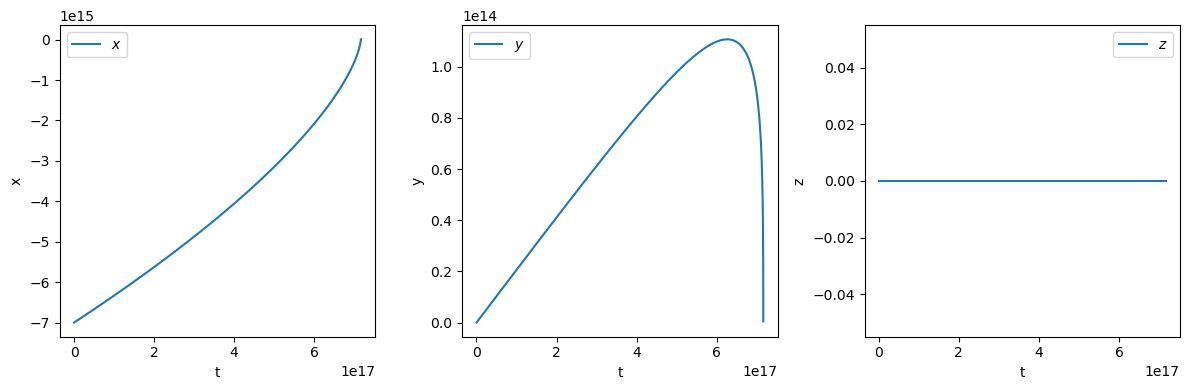

In [199]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(sol['t'],sol['y'][0],label=r'$x$')
ax[1].plot(sol['t'],sol['y'][2],label=r'$y$')
ax[2].plot(sol['t'],sol['y'][4],label=r'$z$')
for i in range(3):
    ax[i].legend()
    ax[i].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].set_ylabel('y')
ax[2].set_ylabel('z')

plt.tight_layout()

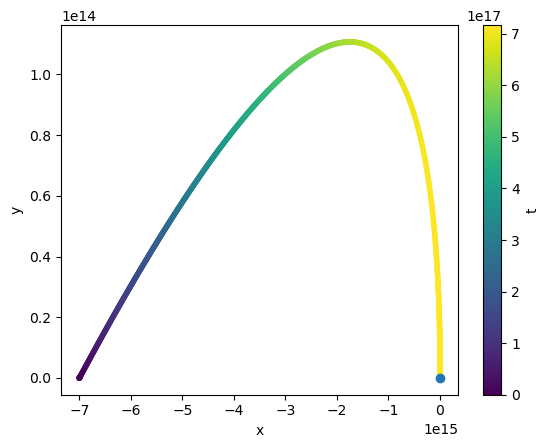

In [200]:
color = sol['t']
plt.scatter(sol['y'][0],sol['y'][2],c=color,marker='.')
plt.colorbar(label='t')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(0,0)

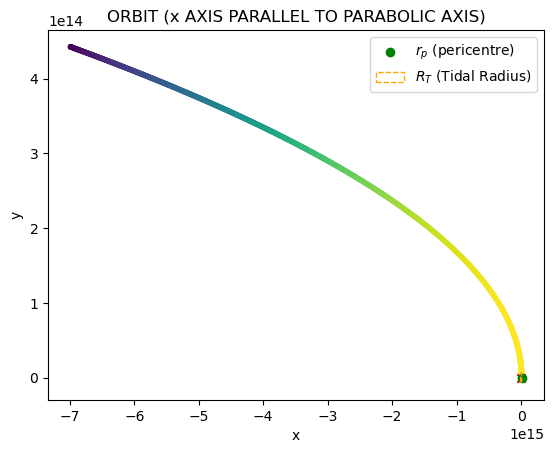

In [201]:
y_p = sol.y_events
R_p_coords = unpack(y_p[0][0])[0]

R_px = R_p_coords[0]
R_py = R_p_coords[1]
theta = np.arctan2(R_py, R_px)

x_coords = sol['y'][0]
y_coords = sol['y'][2]

x_rotated = x_coords * np.cos(theta) + y_coords * np.sin(theta)
y_rotated = -x_coords * np.sin(theta) + y_coords * np.cos(theta)

color = sol['t']
plt.scatter(x_rotated, y_rotated, c=color, marker='.')

plt.scatter(0,0, color='red', marker='x')
pericenter_radius = np.linalg.norm(R_p_coords)
plt.scatter(pericenter_radius, 0, color='green', marker='o', label=r'$r_p$ (pericentre)')
circle_RT = plt.Circle((0, 0), RT, color='orange', linestyle='--', fill=False, label=r'$R_T$ (Tidal Radius)')


plt.title('ORBIT (x AXIS PARALLEL TO PARABOLIC AXIS)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().add_patch(circle_RT)
plt.legend();

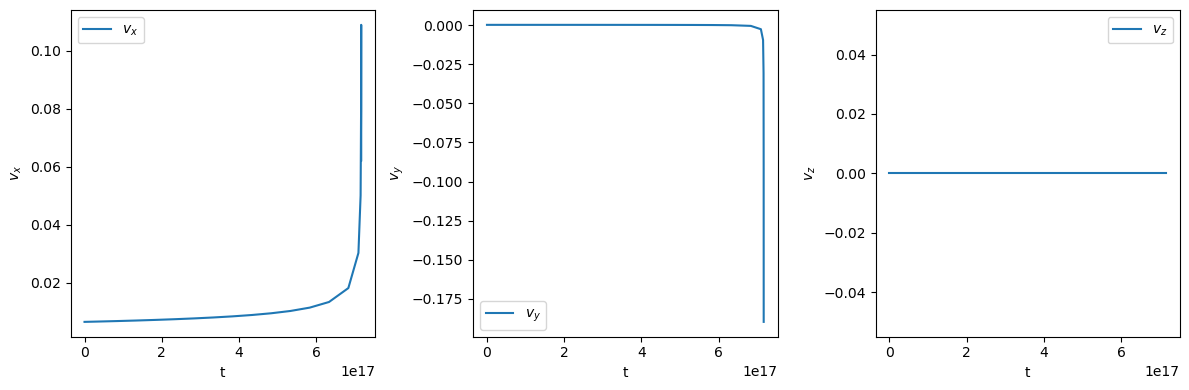

In [202]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(sol['t'][::50],sol['y'][1][::50],label=r'$v_x$')
ax[1].plot(sol['t'][::50],sol['y'][3][::50],label=r'$v_y$')
ax[2].plot(sol['t'][::50],sol['y'][5][::50],label=r'$v_z$')
for i in range(3):
    ax[i].legend()
    ax[i].set_xlabel('t')
ax[0].set_ylabel(r'$v_x$')
ax[1].set_ylabel(r'$v_y$')
ax[2].set_ylabel(r'$v_z$')

plt.tight_layout()

In [203]:
t_p = sol.t_events
y_p = sol.y_events
v_p = unpack(y_p[0][0])[1]
R_p = unpack(y_p[0][0])[0]
print('computed pericentre: %f, true pericenter: %f' % (np.linalg.norm(R_p) , r_p))

computed pericentre: 7000000000033.012695, true pericenter: 6999999999999.998047


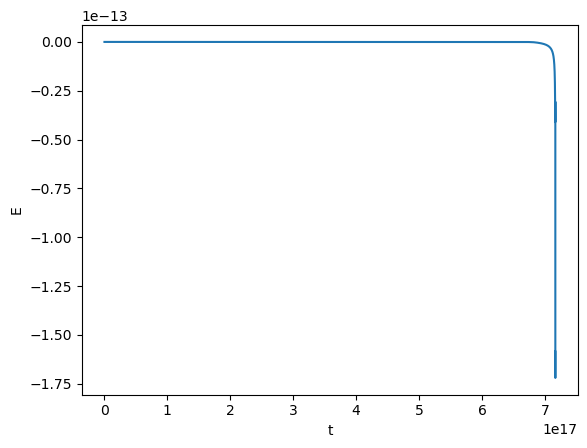

In [204]:
E = []
F = []
t = sol.t
for i in range(len(sol.t)):
    r, v = unpack(sol.y[:,i])
    Ei = np.linalg.norm(v)**2/2 - G*M/np.linalg.norm(r)
    E.append(Ei)
    Fi = 2*G*M*Rstar / np.linalg.norm(r)**3
    F.append(Fi)
plt.plot(t,E)
plt.xlabel('t')
plt.ylabel('E');
# plt.xscale('log')
# plt.yscale('symlog')

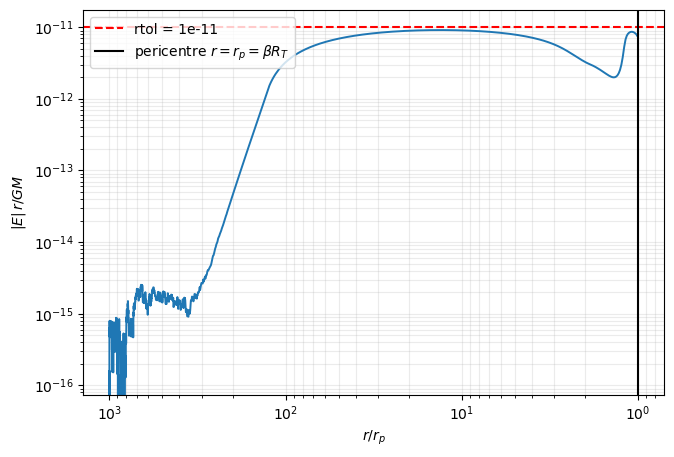

In [207]:
r, v = unpack(sol.y)
rm    = np.sqrt((r*r).sum(0))
E     = 0.5*(v*v).sum(0) - G*M/rm
err_E = np.abs(E) * rm / (G*M)

rtol = 1e-11

fig, ax = plt.subplots(figsize=(7.5,5))
ax.plot(rm/r_p, err_E, lw=1.4)
ax.axhline(rtol,    ls='--', c='red', label=f'rtol = {rtol:.0e}')
ax.axvline(1.0, c='k', label=r'pericentre $r=r_p=\beta R_T$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'$r/r_p$')
ax.set_ylabel(r'$|E|\,r/GM$')
ax.grid(alpha=.25, which='both')
ax.legend(loc='upper left')

# TIDAL FORCE

(7.165724787871708e+17, 6.077097505582954e-17)

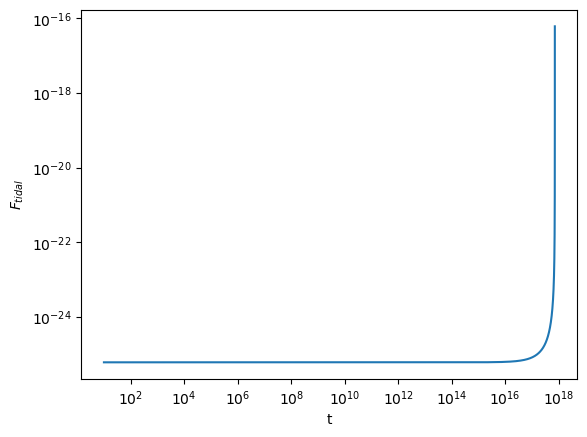

In [18]:
plt.plot(t,F)
plt.xlabel(r'$t$')
plt.ylabel(r'$F_{tidal}$')

ind_peak = np.argmax(F)
t_peak = t[ind_peak]
F_peak = F[ind_peak]
plt.xlabel('t')
plt.ylabel(r'$F_{tidal}$')
plt.xscale('log')
plt.yscale('log')
t_peak, F_peak

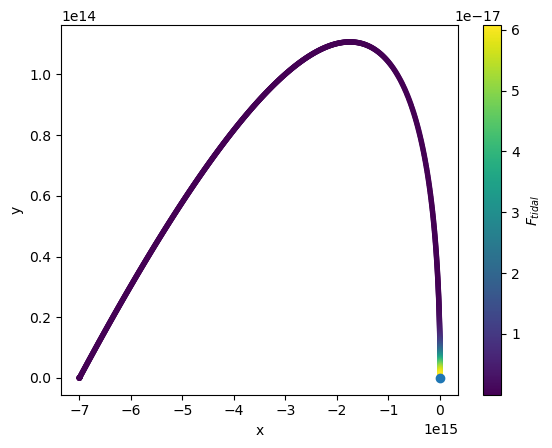

In [19]:
color = F
plt.scatter(sol['y'][0],sol['y'][2],c=color,marker='.')
plt.colorbar(label=r'$F_{tidal}$')
plt.scatter(0,0)
plt.xlabel('x')
plt.ylabel('y');

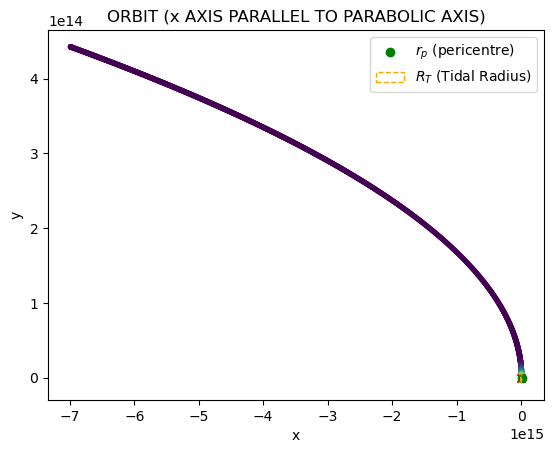

In [20]:
color = F
plt.scatter(x_rotated, y_rotated, c=color, marker='.')

plt.scatter(0,0, color='red', marker='x')
pericenter_radius = np.linalg.norm(R_p_coords)
plt.scatter(pericenter_radius, 0, color='green', marker='o', label=r'$r_p$ (pericentre)')
circle_RT = plt.Circle((0, 0), RT, color='orange', linestyle='--', fill=False, label=r'$R_T$ (Tidal Radius)')


plt.title('ORBIT (x AXIS PARALLEL TO PARABOLIC AXIS)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().add_patch(circle_RT)
plt.legend();

In [21]:
F_peaks = []
t_peaks = []
pericentre_event.terminal = True
betas = np.logspace(0,5,10)
for i in betas:
    r0_i = k * i * RT
    v0_i = np.sqrt(2*G*(M)/r0_i)

    L = np.sqrt(2 * G * M * i * RT)

    vy0_i = L / r0_i
    vx0_i = np.sqrt(v0_i**2 - vy0_i**2)

    y0_i = np.array([-r0_i, vx0_i, 0.0, vy0_i, 0.0, 0.0])

    
    t_span_i = [0, 2 * np.sqrt(r0_i**3 / (2*G*M))]

    sol = solve_ivp(f_prime, t_span_i, y0_i, events=pericentre_event, args=(M,), rtol=1e-11, atol=1e-11)

    F = []
    t = sol.t
    for i in range(len(sol.t)):
        r, v = unpack(sol.y[:,i])
        Fi = 2*G*M*Rstar / np.linalg.norm(r)**3
        F.append(Fi)

    ind_peak = np.argmax(F)
    t_peaks.append(t[ind_peak])
    F_peaks.append(F[ind_peak])


In [22]:
F_peaks

[6.077097505567055e-17,
 1.3092709680692033e-18,
 2.8207387922565213e-20,
 6.0770975055629055e-22,
 1.3092709680691676e-23,
 2.820738792258841e-25,
 6.077097505553392e-27,
 1.309270968068777e-28,
 2.8207387922597755e-30,
 6.077097505563185e-32]

Text(0, 0.5, '$F_{peak}$')

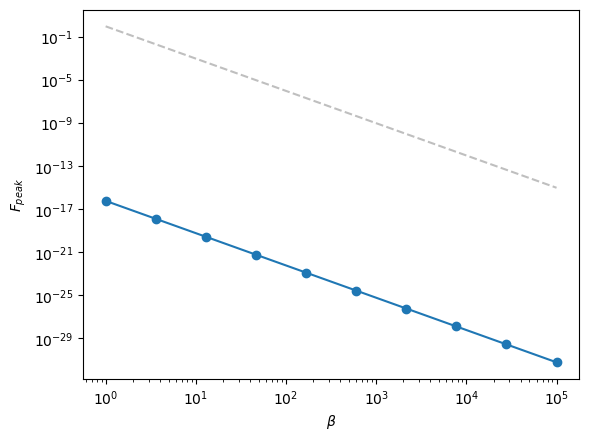

In [23]:
plt.plot(betas,F_peaks)
plt.scatter(betas,F_peaks)

x = np.logspace(0,5,1000)
plt.plot(x, x**(-3),linestyle='--',color='grey',alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$F_{peak}$')

**Step 2 - Debris energy distribution**:

At pericentre, model the disrupted star as $N$ mass elements located at positions $r_p+\delta r_i$ along the radial direction, where $\delta r_i$ is drawn uniformly from $\left[-R_{\star}, R_{\star}\right]$. This is equivalent to assuming a constant-density star; the nonuniform case is treated in the extension below. Each element inherits the centre-of-mass velocity $\mathbf{v}_p$ and acquires a specific orbital energy

$$
\begin{equation*}
E_i=\frac{v_p^2}{2}-\frac{G M_{\bullet}}{r_p+\delta r_i} .
\end{equation*}
$$

The bound debris $\left(E_i<0\right)$ will return to pericentre; the unbound debris $\left(E_i>0\right)$ escapes. Plot the energy distribution $d N / d E$.

# UNIFORM STAR

In [24]:
N = 2000
delta_rs = np.random.uniform(-Rstar, Rstar, N)

In [25]:
Es = np.linalg.norm(v_p)**2/2 - G*M/(r_p+delta_rs)

1.0732500508463953e+18

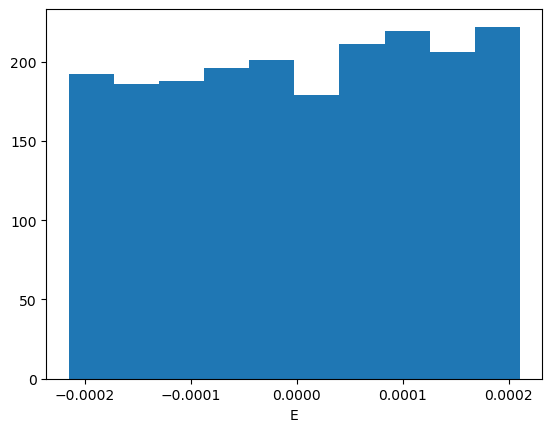

In [26]:
plt.hist(Es)
plt.xlabel('E');
t_ff

In [27]:
# with open('delta_rs.txt', 'w') as f:
#         for ri in delta_rs: f.write(f"{ri}\n")

In [28]:
E_hw = -max(Es)/2
delta_hw = (G*M/(np.linalg.norm(v_p)**2/2-E_hw) - (r_p))
np.linalg.norm(v_p)**2/2 - G*M/(r_p+delta_hw), E_hw

(-0.00010524276012400038, -0.00010524276012400038)

In [29]:
t_ff = np.sqrt(r0**3 / (2*G*M))
t_ff

1.0732500508463953e+18

In [30]:
per_versor = R_p/np.linalg.norm(R_p)
pericentre_event.terminal = False
t_span_hw = [0, 2*t_ff]

r0_hw = (np.linalg.norm(R_p) + delta_hw) * per_versor
y0_hw = np.array([r0_hw[0], v_p[0], r0_hw[1], v_p[1], r0_hw[2], v_p[2]])

In [31]:
sol_hw = solve_ivp(f_prime, t_span_hw, y0_hw, events=pericentre_event, args=(M,), rtol=1e-11, atol=1e-11, max_step=1e15)

In [32]:
t_events_hw = sol_hw.t_events[0][1]

In [232]:
E_hw + G*M**(1/3)*mstar**(2/3)/(2*beta**2*Rstar)

1.1064462252058463e-06

In [33]:
np.pi*G*M/(2*abs(E_hw))**1.5, t_events_hw

(1.5317180278470832e+17, 1.531718035689697e+17)

**Step 3 - Debris return times and fallback rate**:

For each bound debris particle, integrate equation (20) (with the same choice of $\mathbf{a}_{\mathrm{PN}}$ ) starting from $\left(r_p+\delta r_i, \mathbf{v}_p\right)$, and use event detection to find the return time $t_i$ at the next passage through $r=r_p$. In the Newtonian case this can also be computed analytically via Kepler's third law:

$$
\begin{equation*}
t_i^{\mathrm{Kep}}=\frac{\pi G M_{\bullet}}{\left(2\left|E_i\right|\right)^{3 / 2}},
\end{equation*}
$$

which provides an exact benchmark for your integrator. Once the $\left\{t_i\right\}$ are known, sort them and construct the mass fallback rate $\dot{M}(t)=d M / d t$ by numerical differentiation or histogram binning of the cumulative mass distribution.

In [34]:
len(Es[Es<0])

973

In [35]:
Es_bound = Es[Es<0]
delta_rs_bound = delta_rs[Es<0]
len(delta_rs_bound)

973

In [36]:
ts_kep = np.pi*G*M/(2*abs(Es_bound))**1.5
ts_kep[ts_kep>1e20].shape

(7,)

In [37]:
delta_rs_bound[np.argmax(ts_kep)]

-154960264.07476807

In [38]:
t_events = []
y_events = []
t_span_i = [0, 1 * t_ff]
per_versor = R_p/np.linalg.norm(R_p)
pericentre_event.terminal = False


for i in range(len(delta_rs_bound)):
    r0_i = (np.linalg.norm(R_p) + delta_rs_bound[i]) * per_versor
    y0_i = np.array([r0_i[0], v_p[0], r0_i[1], v_p[1], r0_i[2], v_p[2]])

    t_i = ts_kep[i]
    t_span_i = [0, 2 * t_i]

    sol_i = solve_ivp(f_prime, t_span_i, y0_i, events=pericentre_event, args=(M,), rtol=1e-11, atol=1e-11)

    if len(sol_i.t_events[0])>1:
        t_events.append(sol_i.t_events[0][1])
        y_events.append(sol_i.y_events[0][1])
    else:
        t_events.append(0.0)
        y_events.append(np.zeros(6))

    # with open('t_ret_n.txt', 'w') as f:
    #     f.write(f"{t_events}\n")


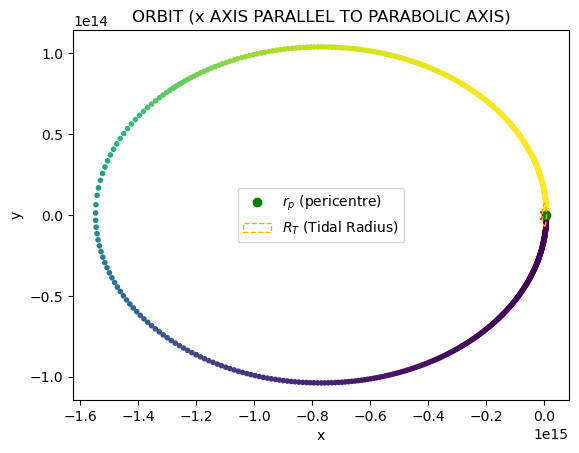

In [39]:
y_p = sol_i.y_events
R_p_coords = unpack(y_p[0][0])[0]

R_px = R_p_coords[0]
R_py = R_p_coords[1]
theta = np.arctan2(R_py, R_px)

x_coords = sol_i['y'][0]
y_coords = sol_i['y'][2]

x_rotated = x_coords * np.cos(theta) + y_coords * np.sin(theta)
y_rotated = -x_coords * np.sin(theta) + y_coords * np.cos(theta)

color = sol_i['t']
plt.scatter(x_rotated, y_rotated, c=color, marker='.')
plt.scatter(0,0, color='red', marker='x')
pericenter_radius = np.linalg.norm(R_p_coords)
plt.scatter(pericenter_radius, 0, color='green', marker='o', label=r'$r_p$ (pericentre)')

circle_RT = plt.Circle((0, 0), RT, color='orange', linestyle='--', fill=False, label=r'$R_T$ (Tidal Radius)')
plt.title('ORBIT (x AXIS PARALLEL TO PARABOLIC AXIS)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().add_patch(circle_RT)
plt.legend();

## FALLBACK RATE

In [40]:
t_events = np.array(t_events)
t_events.shape, t_events[t_events>0.0].shape

((973,), (973,))

In [41]:
t_events-ts_kep

array([2.03801635e+09, 1.48197232e+08, 1.23300870e+09, 7.77189248e+08,
       2.32156634e+09, 3.17843024e+08, 2.44847936e+08, 1.81200832e+14,
       1.36061784e+08, 5.28286746e+09, 1.63943104e+08, 3.16668564e+11,
       8.72958368e+08, 3.96736125e+10, 2.80230733e+10, 2.50418125e+09,
       1.38088556e+10, 1.30852278e+10, 1.81861824e+08, 1.73945968e+08,
       6.97636624e+08, 1.49879128e+08, 2.59219808e+08, 3.67724544e+08,
       6.70066701e+09, 2.75831462e+09, 1.44319824e+09, 8.80751206e+09,
       1.64023448e+08, 1.51549024e+09, 9.13088128e+08, 2.86601408e+08,
       4.82658445e+09, 1.16293995e+11, 9.66180736e+08, 6.36768528e+08,
       1.36499608e+08, 2.12302160e+08, 4.71273760e+08, 2.11910192e+08,
       9.07483392e+08, 1.32044970e+09, 2.01916528e+08, 5.20676048e+08,
       2.10871096e+08, 2.95948304e+08, 2.76260336e+08, 1.00764218e+09,
       2.85809200e+08, 1.53034472e+10, 6.08094064e+08, 1.35726664e+08,
       1.57437976e+08, 4.96210912e+08, 1.46939016e+08, 1.10909542e+09,
      

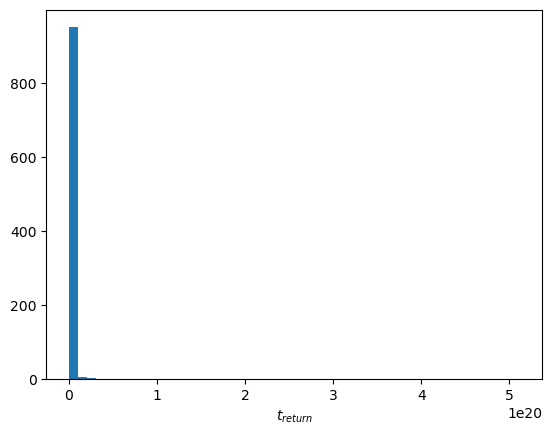

In [42]:
hist = plt.hist((t_events[(t_events>0.0) & (t_events<1e21)]),50)
plt.xlabel(r'$t_{return}$');

In [43]:
min(t_events)

5.2515325429993544e+16

M_peak = 6.226e-13 at time t_peak = 6.782e+16


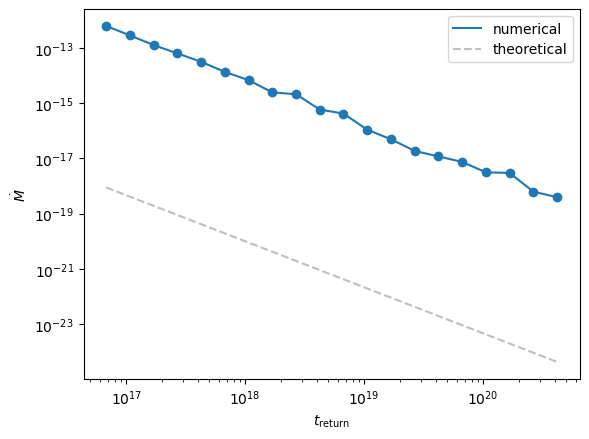

In [44]:
valid_t_events = t_events[t_events > 0.0]
num_bins = 20

min_t_plot = np.min(valid_t_events)
max_t_plot = np.max(valid_t_events)

log_bins = np.logspace(np.log10(min_t_plot), np.log10(max_t_plot), num_bins + 1)
counts, bin_edges = np.histogram(valid_t_events, bins=log_bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths = np.diff(bin_edges)

m_debris_particle = mstar / N

# only consider bins where counts are not zero
dm_dt_numerical = (counts * m_debris_particle) / bin_widths

valid_indices = dm_dt_numerical > 0
bin_centers_filtered = bin_centers[valid_indices]
dm_dt_numerical_filtered = dm_dt_numerical[valid_indices]


if len(dm_dt_numerical_filtered) > 0:
    peak_idx = np.argmax(dm_dt_numerical_filtered)
    t_peak = bin_centers_filtered[peak_idx]
    M_peak = dm_dt_numerical_filtered[peak_idx]
    print(f'M_peak = %.3e at time t_peak = %.3e' % (M_peak, t_peak) )

plt.plot(bin_centers_filtered, dm_dt_numerical_filtered,label='numerical')
plt.scatter(bin_centers_filtered, dm_dt_numerical_filtered)

plt.plot(bin_centers, 1e10 * bin_centers**(-5/3),linestyle='--',color='gray',alpha=0.5,label='theoretical')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{\text{return}}$')
plt.ylabel(r'$\dot{M}$')
plt.legend();

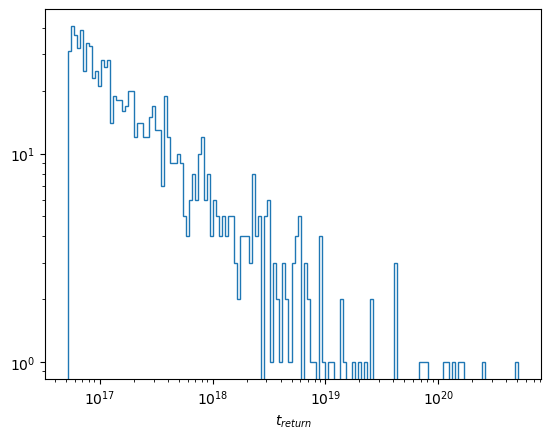

In [45]:
t_min_sim = np.min(t_events)
t_max_sim = np.max(t_events)

custom_bins = np.logspace(np.log10(t_min_sim * 0.99), np.log10(t_max_sim), 150)

plt.hist(t_events, bins=custom_bins, density=False, histtype='step')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{return}$');

# PARAMETER SURVEY

## Over $\beta$

In [47]:
betas = np.linspace(1,5,10)
N = 2000
m_debris_particle = mstar / N

In [150]:
def t_Mdot_peak(beta_j, eta_j, delta_rs_profile):
    M_current_bh = M * eta_j
    RT_current = Rstar * (M_current_bh / mstar)**(1/3)
    r0_j = k * beta_j * RT_current
    
    v0_j = np.sqrt(2*G*M_current_bh/r0_j) 
    L_j = np.sqrt(2 * G * M_current_bh * beta_j * RT_current) 

    vy0_j = L_j / r0_j
    vx0_j = np.sqrt(v0_j**2 - vy0_j**2)
    y0_j = np.array([-r0_j, vx0_j, 0.0, vy0_j, 0.0, 0.0])

    t_span_j = [0, 2 * np.sqrt(r0_j**3 / (2*G*M_current_bh))] 
    sol_ic_j = solve_ivp(f_prime, t_span_j, y0_j, events=pericentre_event, rtol=1e-11, atol=1e-11, args=(M_current_bh,)) 

    if len(sol_ic_j.y_events[0]) == 0:
        return np.nan, np.nan

    v_p_j = unpack(sol_ic_j.y_events[0][0])[1]
    R_p_j = unpack(sol_ic_j.y_events[0][0])[0]

    t_events_j = []
    per_versor_j = R_p_j / np.linalg.norm(R_p_j)
    pericentre_event.terminal = False
    
    Es_j = np.linalg.norm(v_p_j)**2/2 - G*M_current_bh/(np.linalg.norm(R_p_j) + delta_rs_profile)
    
    Es_bound_j = Es_j[Es_j < 0]
    delta_rs_bound_j = delta_rs_profile[Es_j < 0]
    ts_kep_j = np.pi * G * M_current_bh / (2 * abs(Es_bound_j))**1.5 

    for i in range(len(delta_rs_bound_j)):
        r0_i = (np.linalg.norm(R_p_j) + delta_rs_bound_j[i]) * per_versor_j
        y0_i = np.array([r0_i[0], v_p_j[0], r0_i[1], v_p_j[1], r0_i[2], v_p_j[2]])
        t_span_i = [0, 2 * ts_kep_j[i]]

        sol_j = solve_ivp(f_prime, t_span_i, y0_i, events=pericentre_event, rtol=1e-11, atol=1e-11, args=(M_current_bh,)) 

        if len(sol_j.t_events[0]) == 0:
            t_events_j.append(0.0)
        elif len(sol_j.t_events[0]) > 1: 
            t_events_j.append(sol_j.t_events[0][1])
        else: 
            if sol_j.t_events[0][0] > ts_kep_j[i]/100:
                t_events_j.append(sol_j.t_events[0][0])
            else: 
                t_events_j.append(0.0)
                
    t_events_j = np.array(t_events_j)
    valid_t = t_events_j[t_events_j > 0.0]
    if len(valid_t) == 0: return np.nan, np.nan

    custom_bins = np.logspace(np.log10(np.min(valid_t) * 0.99), np.log10(np.max(valid_t)), 150)
    counts_j, bin_edges_j = np.histogram(t_events_j, bins=custom_bins)

    bin_centers_j = (bin_edges_j[:-1] + bin_edges_j[1:]) / 2
    bin_widths_j = np.diff(bin_edges_j)

    # the mass is updated according to the profile
    m_particle_dyn = mstar / len(delta_rs_profile)
    dm_dt_numerical_j = (counts_j * m_particle_dyn) / bin_widths_j

    valid_indices_j = dm_dt_numerical_j > 0
    if not np.any(valid_indices_j): return np.nan, np.nan
    
    bin_centers_j_filtered = bin_centers_j[valid_indices_j]
    dm_dt_numerical_j_filtered = dm_dt_numerical_j[valid_indices_j]
    print(f'M_peak = %.3e at time t_peak_j = %.3e' % (dm_dt_numerical_j_filtered[peak_idx_j], bin_centers_j_filtered[peak_idx_j]) )


    peak_idx_j = np.argmax(dm_dt_numerical_j_filtered)
    return bin_centers_j_filtered[peak_idx_j], dm_dt_numerical_j_filtered[peak_idx_j]


In [49]:
t_peaks_beta = []
Mdot_peaks_beta = []
eta=1

for beta_j in betas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta, delta_rs)
    t_peaks_beta.append(t_p_j)
    Mdot_peaks_beta.append(M_p_j)

[6.98600000e+12 4.42497458e+11 0.00000000e+00]
973
M_peak = 8.671e-13 at time t_peak_j = 5.706e+16
[1.00908889e+13 6.39162994e+11 0.00000000e+00]
973
M_peak = 2.865e-13 at time t_peak_j = 1.728e+17
[1.31957778e+13 8.35828531e+11 0.00000000e+00]
973
M_peak = 1.279e-13 at time t_peak_j = 3.873e+17
[1.63006667e+13 1.03249407e+12 0.00000000e+00]
973
M_peak = 6.774e-14 at time t_peak_j = 7.311e+17
[1.94055556e+13 1.22915960e+12 0.00000000e+00]
973
M_peak = 4.011e-14 at time t_peak_j = 1.235e+18
[2.25104444e+13 1.42582514e+12 0.00000000e+00]
973
M_peak = 2.568e-14 at time t_peak_j = 1.929e+18
[2.56153333e+13 1.62249068e+12 0.00000000e+00]
973
M_peak = 1.742e-14 at time t_peak_j = 2.844e+18
[2.87202222e+13 1.81915622e+12 0.00000000e+00]
973
M_peak = 1.235e-14 at time t_peak_j = 4.010e+18
[3.18251111e+13 2.01582175e+12 0.00000000e+00]
973
M_peak = 9.298e-15 at time t_peak_j = 5.458e+18
[3.49300000e+13 2.21248729e+12 0.00000000e+00]
973
M_peak = 7.031e-15 at time t_peak_j = 7.218e+18


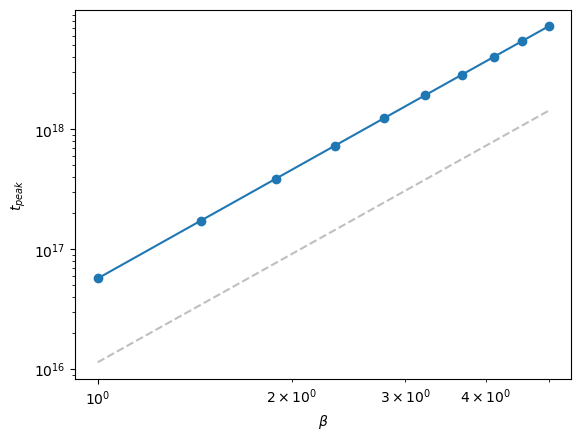

In [50]:
plt.scatter(betas, t_peaks_beta)
plt.plot(betas, t_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)

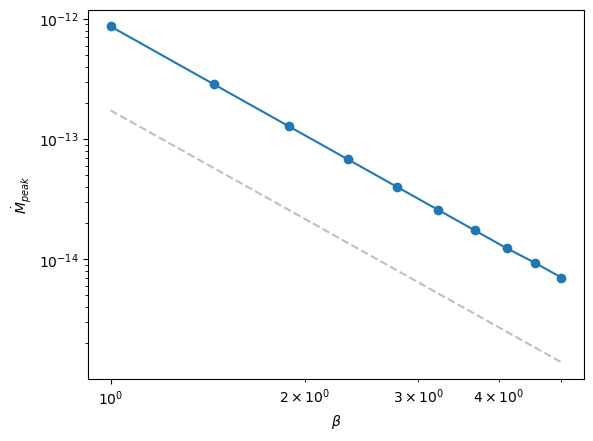

In [51]:
plt.scatter(betas, Mdot_peaks_beta)
plt.plot(betas, Mdot_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)

## Over $\eta$

In [52]:
etas = np.logspace(-1,2,10)
etas*M/mstar

array([1.00000000e+05, 2.15443469e+05, 4.64158883e+05, 1.00000000e+06,
       2.15443469e+06, 4.64158883e+06, 1.00000000e+07, 2.15443469e+07,
       4.64158883e+07, 1.00000000e+08])

In [53]:
t_peaks_eta = []
Mdot_peaks_eta = []
beta_j=betas[0]

for eta_j in etas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta_j, delta_rs)
    t_peaks_eta.append(t_p_j)
    Mdot_peaks_eta.append(M_p_j)

[3.24261396e+12 2.05389126e+11 0.00000000e+00]
973
M_peak = 2.785e-12 at time t_peak_j = 1.773e+16
[4.18799697e+12 2.65270257e+11 0.00000000e+00]
973
M_peak = 1.885e-12 at time t_peak_j = 2.622e+16
[5.40900609e+12 3.42609711e+11 0.00000000e+00]
973
M_peak = 1.278e-12 at time t_peak_j = 3.870e+16
[6.98600000e+12 4.42497458e+11 0.00000000e+00]
973
M_peak = 8.671e-13 at time t_peak_j = 5.706e+16
[9.02276596e+12 5.71507443e+11 0.00000000e+00]
973
M_peak = 5.890e-13 at time t_peak_j = 8.404e+16
[1.16533504e+13 7.38130247e+11 0.00000000e+00]
973
M_peak = 4.003e-13 at time t_peak_j = 1.237e+17
[1.50508807e+13 9.53331873e+11 0.00000000e+00]
973
M_peak = 2.723e-13 at time t_peak_j = 1.819e+17
[1.94389600e+13 1.23127546e+12 0.00000000e+00]
973
M_peak = 1.852e-13 at time t_peak_j = 2.674e+17
[2.51063823e+13 1.59025341e+12 0.00000000e+00]
973
M_peak = 1.261e-13 at time t_peak_j = 3.930e+17
[3.24261396e+13 2.05389126e+12 0.00000000e+00]
973
M_peak = 8.790e-14 at time t_peak_j = 5.773e+17


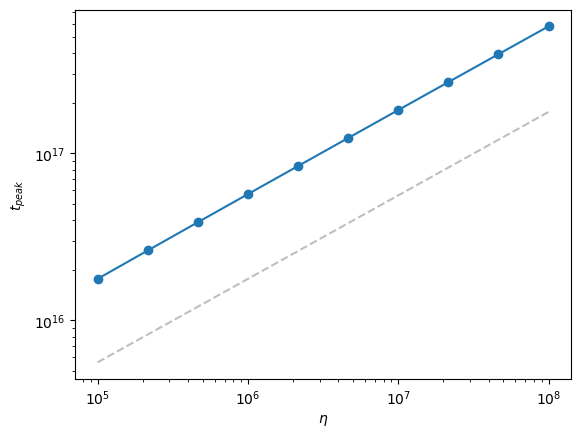

In [54]:
plt.scatter(etas*M/mstar, t_peaks_eta)
plt.plot(etas*M/mstar, t_peaks_eta)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$') # here the true eta = M_bh/mstar
plt.ylabel(r'$t_{peak}$')
plt.plot(etas*M/mstar, t_peaks_eta[0]*etas**(0.5), linestyle='--', color='grey', alpha=0.5)

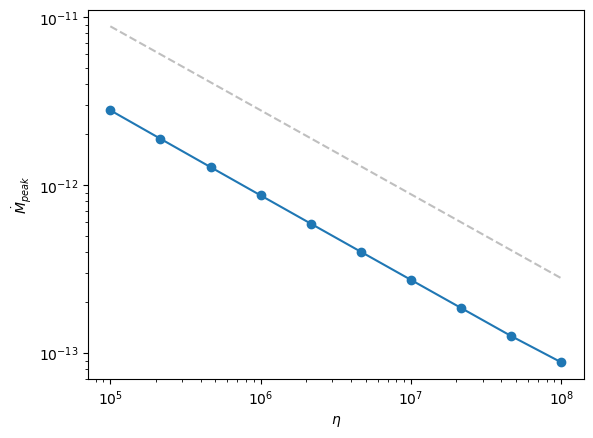

In [55]:
plt.scatter(etas*M/mstar, Mdot_peaks_eta)
plt.plot(etas*M/mstar, Mdot_peaks_eta)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(etas*M/mstar, Mdot_peaks_eta[0]*etas**(-0.5), linestyle='--', color='grey', alpha=0.5)

# SPHERICAL UNIFORM STAR

## FALLBACK RATE

In [56]:
points = []
while len(points)<N:
    pt = np.random.uniform(-Rstar, Rstar, 3)
    if np.linalg.norm(pt) <= Rstar: points.append(pt)

delta_rs = np.array(points)[:,0]
Es = np.linalg.norm(v_p)**2/2 - G*M/(r_p+delta_rs)

1.0732500508463953e+18

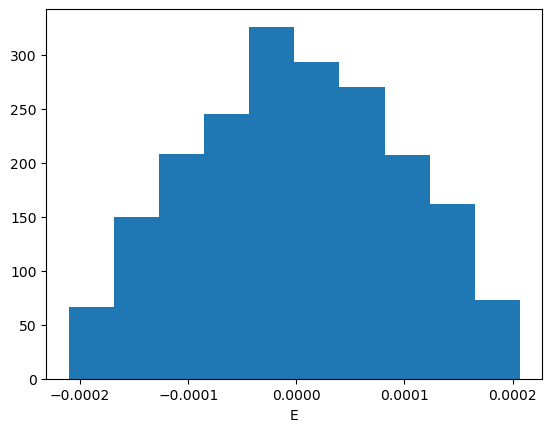

In [57]:
plt.hist(Es)
plt.xlabel('E');
t_ff

In [58]:
len(Es[Es<0])

1006

In [59]:
Es_bound = Es[Es<0]
delta_rs_bound = delta_rs[Es<0]

ts_kep = np.pi*G*M/(2*abs(Es_bound))**1.5

In [60]:
t_events = []
y_events = []
t_span_i = [0, 1 * t_ff]
per_versor = R_p/np.linalg.norm(R_p)
pericentre_event.terminal = False


for i in range(len(delta_rs_bound)):
    r0_i = (np.linalg.norm(R_p) + delta_rs_bound[i]) * per_versor
    y0_i = np.array([r0_i[0], v_p[0], r0_i[1], v_p[1], r0_i[2], v_p[2]])

    t_i = ts_kep[i]
    t_span_i = [0, 2 * t_i]

    sol_i = solve_ivp(f_prime, t_span_i, y0_i, events=pericentre_event, args=(M,), rtol=1e-11, atol=1e-11)

    if len(sol_i.t_events[0])>1:
        t_events.append(sol_i.t_events[0][1])
        y_events.append(sol_i.y_events[0][1])
    else:
        t_events.append(0.0)
        y_events.append(np.zeros(6))

    # with open('t_ret_n.txt', 'w') as f:
    #     f.write(f"{t_events}\n")


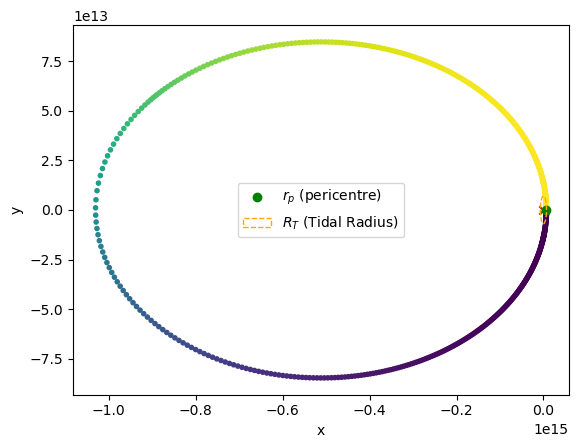

In [61]:
y_p = sol_i.y_events
R_p_coords = unpack(y_p[0][0])[0]

R_px = R_p_coords[0]
R_py = R_p_coords[1]
theta = np.arctan2(R_py, R_px)

x_coords = sol_i['y'][0]
y_coords = sol_i['y'][2]

x_rotated = x_coords * np.cos(theta) + y_coords * np.sin(theta)
y_rotated = -x_coords * np.sin(theta) + y_coords * np.cos(theta)

color = sol_i['t']
plt.scatter(x_rotated, y_rotated, c=color, marker='.')
plt.scatter(0,0, color='red', marker='x')
pericenter_radius = np.linalg.norm(R_p_coords)
plt.scatter(pericenter_radius, 0, color='green', marker='o', label=r'$r_p$ (pericentre)')

circle_RT = plt.Circle((0, 0), RT, color='orange', linestyle='--', fill=False, label=r'$R_T$ (Tidal Radius)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().add_patch(circle_RT)
plt.legend();

In [62]:
t_events = np.array(t_events)
t_events.shape, t_events[t_events>0.0].shape

((1006,), (1006,))

In [63]:
t_events-ts_kep

array([4.02499840e+08, 2.48132378e+09, 2.41249418e+10, ...,
       7.35262176e+08, 5.87517478e+10, 3.64850688e+08])

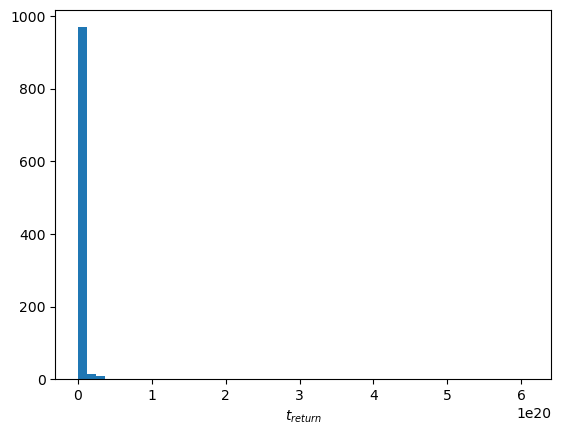

In [64]:
hist = plt.hist((t_events[(t_events>0.0) & (t_events<1e21)]),50)
plt.xlabel(r'$t_{return}$');

In [65]:
min(t_events)

5.4200756809612184e+16

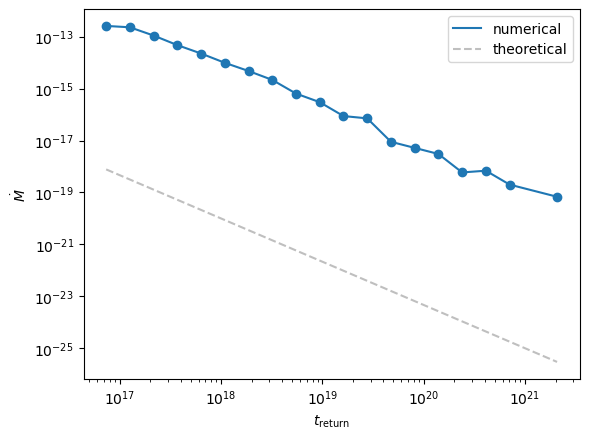

In [66]:
valid_t_events = t_events[t_events > 0.0]
num_bins = 20

min_t_plot = np.min(valid_t_events)
max_t_plot = np.max(valid_t_events)

log_bins = np.logspace(np.log10(min_t_plot), np.log10(max_t_plot), num_bins + 1)
counts, bin_edges = np.histogram(valid_t_events, bins=log_bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths = np.diff(bin_edges)

m_debris_particle = mstar / N

# only consider bins where counts are not zero
dm_dt_numerical = (counts * m_debris_particle) / bin_widths

valid_indices = dm_dt_numerical > 0
bin_centers_filtered = bin_centers[valid_indices]
dm_dt_numerical_filtered = dm_dt_numerical[valid_indices]


plt.plot(bin_centers_filtered, dm_dt_numerical_filtered,label='numerical')
plt.scatter(bin_centers_filtered, dm_dt_numerical_filtered)

plt.plot(bin_centers, 1e10 * bin_centers**(-5/3),linestyle='--',color='gray',alpha=0.5,label='theoretical')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{\text{return}}$')
plt.ylabel(r'$\dot{M}$')
plt.legend();

M_peak = 4.147e-13 at time t_peak = 7.438e+16


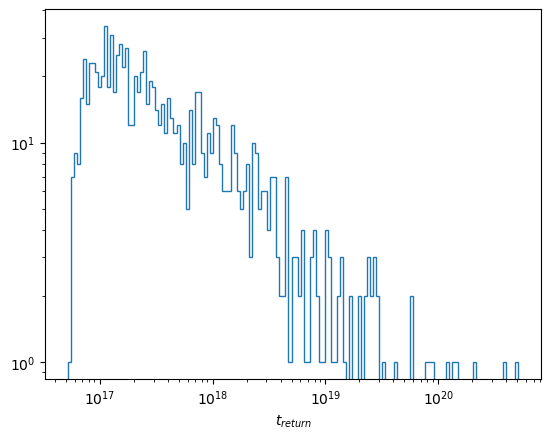

In [67]:
log_bins = np.logspace(np.log10(min_t_plot * 0.99), np.log10(max_t_plot), 150)
counts, bin_edges = np.histogram(valid_t_events, bins=log_bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths = np.diff(bin_edges)

dm_dt_numerical = (counts * m_debris_particle) / bin_widths

valid_indices = dm_dt_numerical > 0
bin_centers_filtered = bin_centers[valid_indices]
dm_dt_numerical_filtered = dm_dt_numerical[valid_indices]


if len(dm_dt_numerical_filtered) > 0:
    peak_idx = np.argmax(dm_dt_numerical_filtered)
    t_peak = bin_centers_filtered[peak_idx]
    M_peak = dm_dt_numerical_filtered[peak_idx]
    print(f'M_peak = %.3e at time t_peak = %.3e' % (M_peak, t_peak) )

plt.hist(t_events, bins=custom_bins, density=False, histtype='step')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{return}$');

# PARAMETER SURVEY

## Over $\beta$

In [109]:
betas = np.linspace(1,5,10)
N = 2000
m_debris_particle = mstar / N

In [111]:
t_peaks_beta = []
Mdot_peaks_beta = []
eta=1

for beta_j in betas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta, delta_rs)
    t_peaks_beta.append(t_p_j)
    Mdot_peaks_beta.append(M_p_j)

[6.98600000e+12 4.42497458e+11 0.00000000e+00]
1006
M_peak = 4.147e-13 at time t_peak_j = 7.438e+16
[1.00908889e+13 6.39162994e+11 0.00000000e+00]
1006
M_peak = 1.371e-13 at time t_peak_j = 2.252e+17
[1.31957778e+13 8.35828531e+11 0.00000000e+00]
1006
M_peak = 6.116e-14 at time t_peak_j = 5.047e+17
[1.63006667e+13 1.03249407e+12 0.00000000e+00]
1006
M_peak = 3.240e-14 at time t_peak_j = 9.527e+17
[1.94055556e+13 1.22915960e+12 0.00000000e+00]
1006
M_peak = 1.919e-14 at time t_peak_j = 1.609e+18
[2.25104444e+13 1.42582514e+12 0.00000000e+00]
1006
M_peak = 1.229e-14 at time t_peak_j = 2.513e+18
[2.56153333e+13 1.62249068e+12 0.00000000e+00]
1006
M_peak = 8.333e-15 at time t_peak_j = 3.705e+18
[2.87202222e+13 1.81915622e+12 0.00000000e+00]
1006
M_peak = 5.910e-15 at time t_peak_j = 5.225e+18
[3.18251111e+13 2.01582175e+12 0.00000000e+00]
1006
M_peak = 4.342e-15 at time t_peak_j = 7.112e+18
[3.49300000e+13 2.21248729e+12 0.00000000e+00]
1006
M_peak = 3.283e-15 at time t_peak_j = 9.405e+18


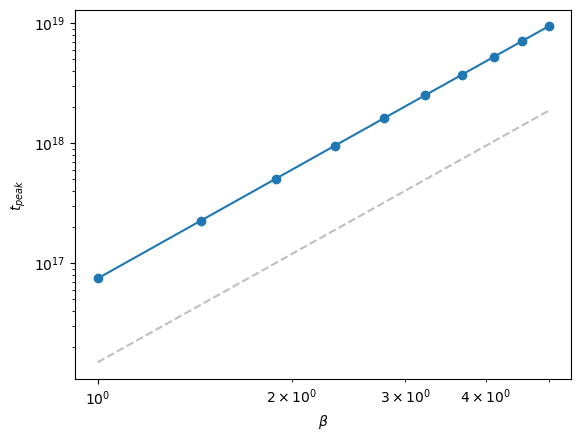

In [112]:
plt.scatter(betas, t_peaks_beta)
plt.plot(betas, t_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)

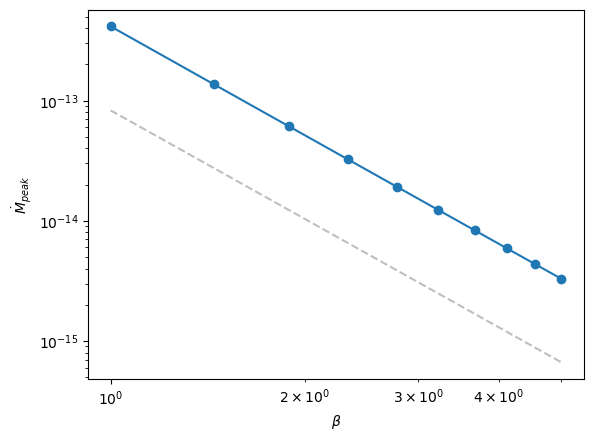

In [113]:
plt.scatter(betas, Mdot_peaks_beta)
plt.plot(betas, Mdot_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)

## Over $\eta$

In [114]:
etas = np.logspace(-1,2,10)
etas*M/mstar

array([1.00000000e+05, 2.15443469e+05, 4.64158883e+05, 1.00000000e+06,
       2.15443469e+06, 4.64158883e+06, 1.00000000e+07, 2.15443469e+07,
       4.64158883e+07, 1.00000000e+08])

In [115]:
t_peaks_eta = []
Mdot_peaks_eta = []
beta_j=betas[0]

for eta_j in etas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta_j, delta_rs)
    t_peaks_eta.append(t_p_j)
    Mdot_peaks_eta.append(M_p_j)

[3.24261396e+12 2.05389126e+11 0.00000000e+00]
1006
M_peak = 1.331e-12 at time t_peak_j = 2.313e+16
[4.18799697e+12 2.65270257e+11 0.00000000e+00]
1006
M_peak = 9.013e-13 at time t_peak_j = 3.419e+16
[5.40900609e+12 3.42609711e+11 0.00000000e+00]
1006
M_peak = 6.110e-13 at time t_peak_j = 5.047e+16
[6.98600000e+12 4.42497458e+11 0.00000000e+00]
1006
M_peak = 4.147e-13 at time t_peak_j = 7.438e+16
[9.02276596e+12 5.71507443e+11 0.00000000e+00]
1006
M_peak = 2.817e-13 at time t_peak_j = 1.095e+17
[1.16533504e+13 7.38130247e+11 0.00000000e+00]
1006
M_peak = 1.915e-13 at time t_peak_j = 1.612e+17
[1.50508807e+13 9.53331873e+11 0.00000000e+00]
1006
M_peak = 1.302e-13 at time t_peak_j = 2.370e+17
[1.94389600e+13 1.23127546e+12 0.00000000e+00]
1006
M_peak = 8.860e-14 at time t_peak_j = 3.484e+17
[2.51063823e+13 1.59025341e+12 0.00000000e+00]
1006
M_peak = 6.030e-14 at time t_peak_j = 5.120e+17
[3.24261396e+13 2.05389126e+12 0.00000000e+00]
1006
M_peak = 4.105e-14 at time t_peak_j = 7.523e+17


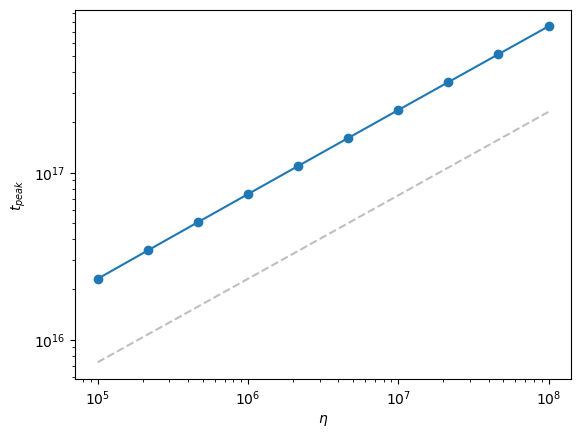

In [116]:
plt.scatter(etas*M/mstar, t_peaks_eta)
plt.plot(etas*M/mstar, t_peaks_eta)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$') # here the true eta = M_bh/mstar
plt.ylabel(r'$t_{peak}$')
plt.plot(etas*M/mstar, t_peaks_eta[0]*etas**(0.5), linestyle='--', color='grey', alpha=0.5)

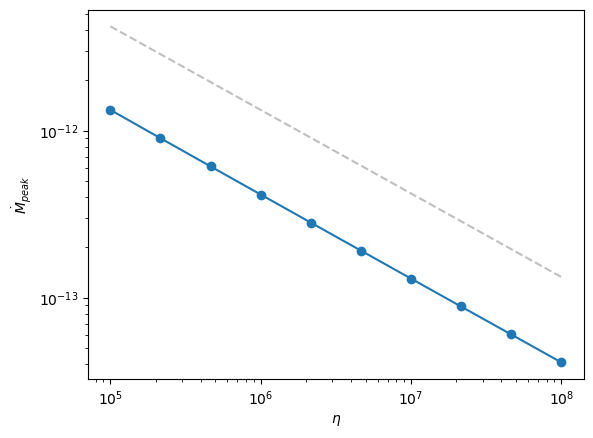

In [117]:
plt.scatter(etas*M/mstar, Mdot_peaks_eta)
plt.plot(etas*M/mstar, Mdot_peaks_eta)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(etas*M/mstar, Mdot_peaks_eta[0]*etas**(-0.5), linestyle='--', color='grey', alpha=0.5)

# NON-UNIFORM STAR: POLYTROPIC DENSITY PROFILE

In a plytropic profile the distribution of mass is such that

$ \rho(\delta r) \propto (1-\delta r^2/ R_{\star}^2)^n$

If we consider the Lane-Emden equation, for stars two different polytropic density profiles are possible: either $n = 1.5$ for lower-mass stars or $n = 3$ for more massive stars.

In [151]:
N = 2000

def polytropic_delta_rs(N_samples, n_polytrope):
    delta_rs_sampled = []
    while len(delta_rs_sampled) < N_samples:
        dr_proposal = np.random.uniform(-Rstar, Rstar)
        prob = (1 - (dr_proposal / Rstar)**2)**n_polytrope

        if np.random.rand() < prob: delta_rs_sampled.append(dr_proposal)
    return np.array(delta_rs_sampled)

## $n = 3/2$

In [152]:
delta_rs_3_2 = polytropic_delta_rs(N, 3/2)
Es_3_2 = np.linalg.norm(v_p)**2/2 - G*M/(r_p+delta_rs_3_2)

1.0732500508463953e+18

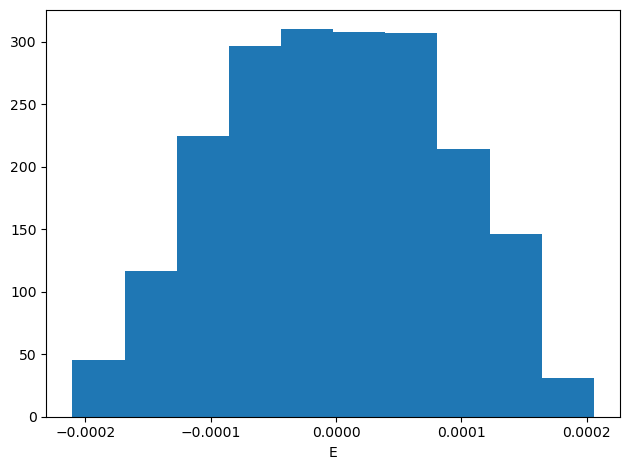

In [153]:
plt.hist(Es_3_2)
plt.xlabel('E')
plt.tight_layout();
t_ff

In [154]:
t_ff = np.sqrt(r0**3 / (2*G*M))
t_ff

1.0732500508463953e+18

In [155]:
per_versor = R_p/np.linalg.norm(R_p)
pericentre_event.terminal = False

In [156]:
len(Es_3_2[Es_3_2<0])

1006

In [157]:
Es_3_2_bound = Es_3_2[Es_3_2<0]
delta_rs_3_2_bound = delta_rs_3_2[Es_3_2<0]
len(delta_rs_3_2_bound)

1006

In [158]:
ts_kep_3_2 = np.pi*G*M/(2*abs(Es_3_2_bound))**1.5

In [159]:
t_events_3_2 = []

for i in range(len(delta_rs_3_2_bound)):
    r0_i_3_2 = (np.linalg.norm(R_p) + delta_rs_3_2_bound[i]) * per_versor
    y0_i_3_2 = np.array([r0_i_3_2[0], v_p[0], r0_i_3_2[1], v_p[1], r0_i_3_2[2], v_p[2]])

    t_span_i_3_2 = [0, 2 * ts_kep_3_2[i]]

    sol_i_3_2 = solve_ivp(f_prime, t_span_i_3_2, y0_i_3_2, events=pericentre_event, args=(M,), rtol=1e-11, atol=1e-11)

    if len(sol_i_3_2.t_events[0])>1:
        t_events_3_2.append(sol_i_3_2.t_events[0][1])
    else:
        t_events_3_2.append(0.0)

    # with open('t_ret_n.txt', 'w') as f:
    #     f.write(f"{t_events_3_2}\n")


## FALLBACK RATE

In [160]:
t_events_3_2 = np.array(t_events_3_2)

In [161]:
t_events-ts_kep

array([4.02499840e+08, 2.48132378e+09, 2.41249418e+10, ...,
       7.35262176e+08, 5.87517478e+10, 3.64850688e+08])

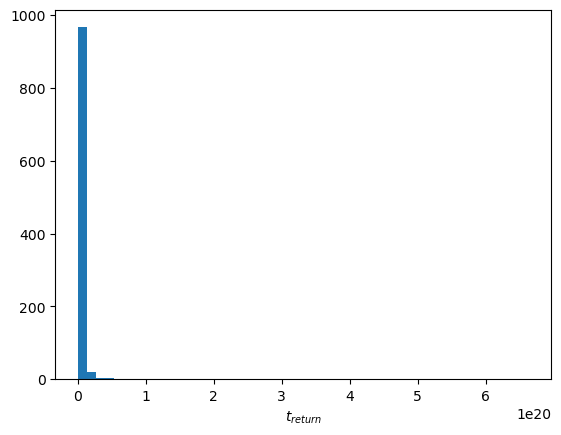

In [162]:
hist = plt.hist((t_events_3_2[(t_events_3_2>0.0) & (t_events_3_2<1e21)]),50)
plt.xlabel(r'$t_{return}$');

M_peak_3_2 = 1.974e-13 at time t_peak_3_2 = 8.718e+16


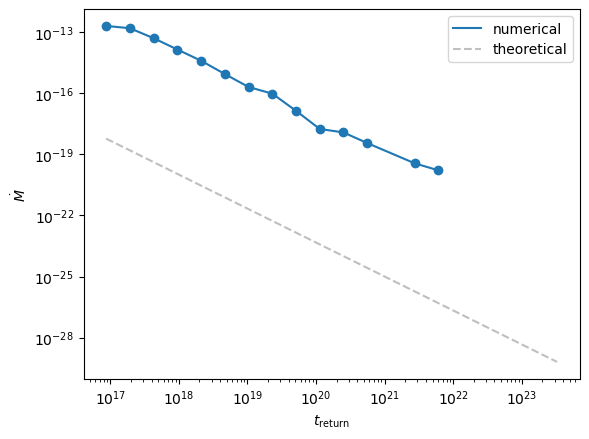

In [163]:
valid_t_events_3_2 = t_events_3_2[t_events_3_2 > 0.0]
num_bins = 20

min_t_plot = np.min(valid_t_events_3_2)
max_t_plot = np.max(valid_t_events_3_2)

log_bins = np.logspace(np.log10(min_t_plot), np.log10(max_t_plot), num_bins + 1)
counts, bin_edges = np.histogram(valid_t_events_3_2, bins=log_bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths = np.diff(bin_edges)

m_debris_particle = mstar / N

# only consider bins where counts are not zero
dm_dt_numerical = (counts * m_debris_particle) / bin_widths

valid_indices = dm_dt_numerical > 0
bin_centers_filtered_3_2 = bin_centers[valid_indices]
dm_dt_numerical_filtered_3_2 = dm_dt_numerical[valid_indices]


if len(dm_dt_numerical_filtered_3_2) > 0:
    peak_idx = np.argmax(dm_dt_numerical_filtered_3_2)
    t_peak_3_2 = bin_centers_filtered_3_2[peak_idx]
    M_peak_3_2 = dm_dt_numerical_filtered_3_2[peak_idx]
    print(f'M_peak_3_2 = %.3e at time t_peak_3_2 = %.3e' % (M_peak_3_2, t_peak_3_2) )

plt.plot(bin_centers_filtered_3_2, dm_dt_numerical_filtered_3_2,label='numerical')
plt.scatter(bin_centers_filtered_3_2, dm_dt_numerical_filtered_3_2)

plt.plot(bin_centers_filtered_3_2, 1e10 * bin_centers_filtered_3_2**(-5/3),linestyle='--',color='gray',alpha=0.5,label='theoretical')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{\text{return}}$')
plt.ylabel(r'$\dot{M}$')
plt.legend();

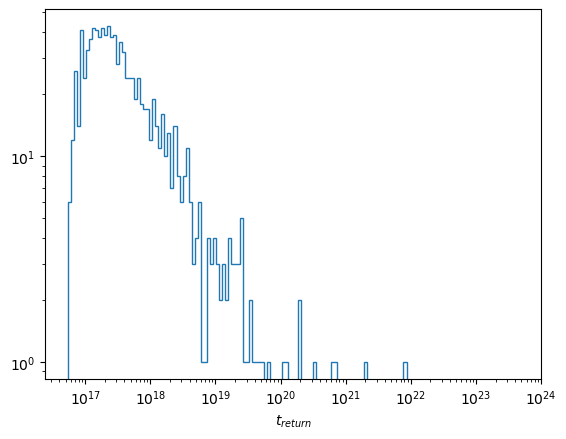

In [164]:
t_min_sim_3_2 = np.min(t_events_3_2)
t_max_sim_3_2 = np.max(t_events_3_2)

custom_bins_3_2 = np.logspace(np.log10(t_min_sim_3_2 * 0.99), np.log10(t_max_sim_3_2), 150)

plt.hist(t_events_3_2, bins=custom_bins_3_2, density=False, histtype='step')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{return}$');

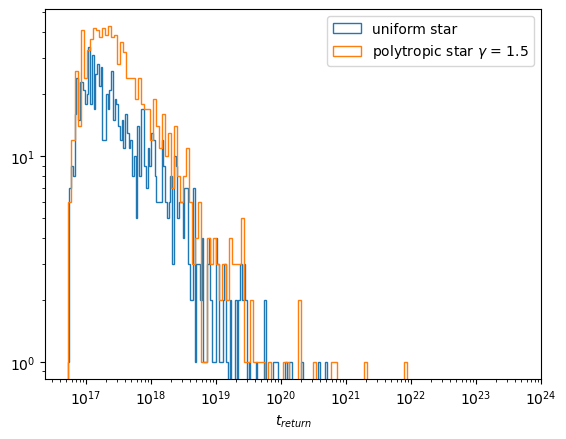

In [273]:
t_min_sim_3_2 = np.min(t_events_3_2)
t_max_sim_3_2 = np.max(t_events_3_2)

custom_bins_3_2 = np.logspace(np.log10(t_min_sim_3_2 * 0.99), np.log10(t_max_sim_3_2), 150)

plt.hist(t_events, bins=custom_bins, density=False, histtype='step', label='uniform star')
plt.hist(t_events_3_2, bins=custom_bins_3_2, density=False, histtype='step', label=r'polytropic star $\gamma$ = 1.5')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{return}$')
plt.legend();

## PARAMETER SURVEY

## Over $\beta$

In [166]:
betas = np.linspace(1,5,10)
N = 2000
m_debris_particle = mstar / N

In [167]:
t_peaks_beta_3_2 = []
Mdot_peaks_beta_3_2 = []
eta=1

for beta_j in betas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta, delta_rs_3_2)
    t_peaks_beta_3_2.append(t_p_j)
    Mdot_peaks_beta_3_2.append(M_p_j)

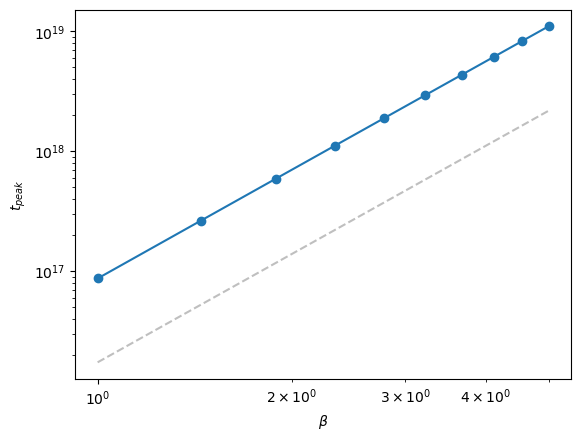

In [168]:
plt.scatter(betas, t_peaks_beta_3_2)
plt.plot(betas, t_peaks_beta_3_2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta_3_2[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)

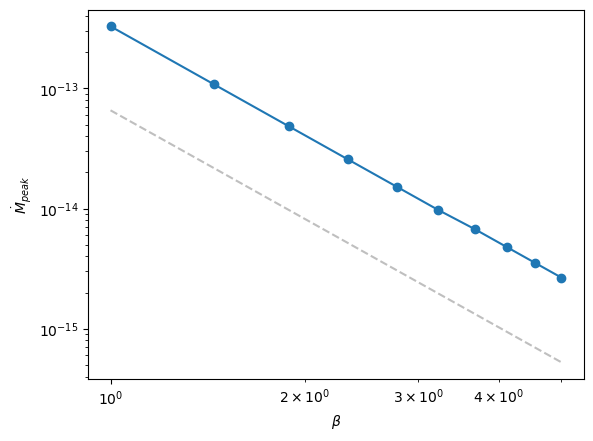

In [169]:
plt.scatter(betas, Mdot_peaks_beta_3_2)
plt.plot(betas, Mdot_peaks_beta_3_2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta_3_2[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)

## Over $\eta$

In [170]:
etas = np.logspace(-1,2,10)
etas*M/mstar

array([1.00000000e+05, 2.15443469e+05, 4.64158883e+05, 1.00000000e+06,
       2.15443469e+06, 4.64158883e+06, 1.00000000e+07, 2.15443469e+07,
       4.64158883e+07, 1.00000000e+08])

In [171]:
t_peaks_eta_3_2 = []
Mdot_peaks_eta_3_2 = []
beta_j=betas[0]

for eta_j in etas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta_j, delta_rs_3_2)
    t_peaks_eta_3_2.append(t_p_j)
    Mdot_peaks_eta_3_2.append(M_p_j)

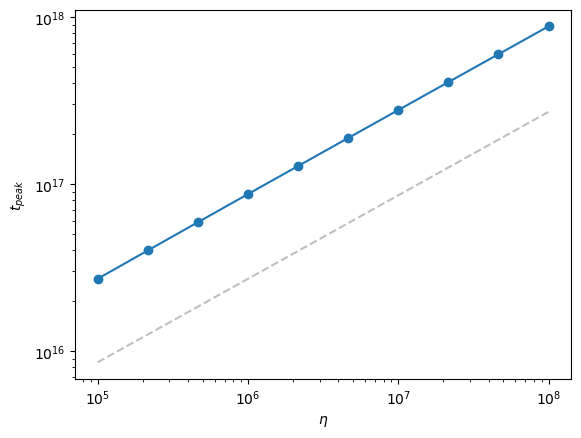

In [172]:
plt.scatter(etas*M/mstar, t_peaks_eta_3_2)
plt.plot(etas*M/mstar, t_peaks_eta_3_2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$') # here the true eta = M_bh/mstar
plt.ylabel(r'$t_{peak}$')
plt.plot(etas*M/mstar, t_peaks_eta_3_2[0]*etas**(0.5), linestyle='--', color='grey', alpha=0.5)

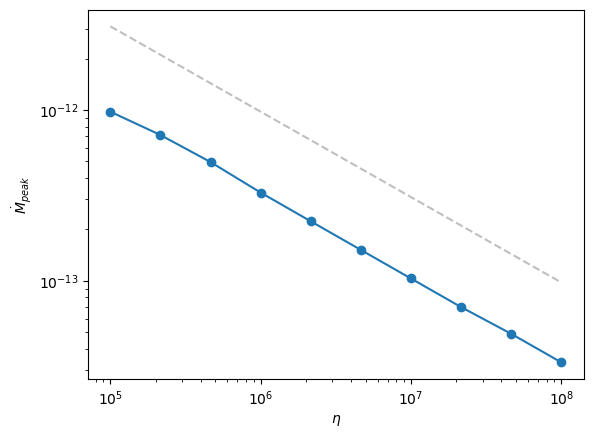

In [173]:
plt.scatter(etas*M/mstar, Mdot_peaks_eta_3_2)
plt.plot(etas*M/mstar, Mdot_peaks_eta_3_2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(etas*M/mstar, Mdot_peaks_eta_3_2[0]*etas**(-0.5), linestyle='--', color='grey', alpha=0.5)

## $\gamma$ = 3

In [208]:
delta_rs_3 = polytropic_delta_rs(N, 3/2)
Es_3 = np.linalg.norm(v_p)**2/2 - G*M/(r_p+delta_rs_3)

1.0732500508463953e+18

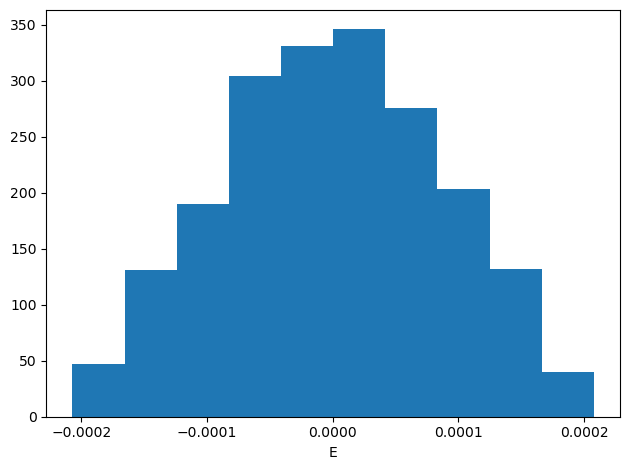

In [209]:
plt.hist(Es_3)
plt.xlabel('E')
plt.tight_layout();
t_ff

In [210]:
t_ff = np.sqrt(r0**3 / (2*G*M))
t_ff

1.0732500508463953e+18

In [211]:
per_versor = R_p/np.linalg.norm(R_p)
pericentre_event.terminal = False

In [212]:
len(Es_3[Es_3<0])

999

In [213]:
Es_3_bound = Es_3[Es_3<0]
delta_rs_3_bound = delta_rs_3[Es_3<0]
len(delta_rs_3_bound)

999

In [214]:
ts_kep_3 = np.pi*G*M/(2*abs(Es_3_bound))**1.5

In [215]:
t_events_3 = []

for i in range(len(delta_rs_3_bound)):
    r0_i_3 = (np.linalg.norm(R_p) + delta_rs_3_bound[i]) * per_versor
    y0_i_3 = np.array([r0_i_3[0], v_p[0], r0_i_3[1], v_p[1], r0_i_3[2], v_p[2]])

    t_span_i_3 = [0, 2 * ts_kep_3[i]]

    sol_i_3 = solve_ivp(f_prime, t_span_i_3, y0_i_3, events=pericentre_event, args=(M,), rtol=1e-11, atol=1e-11)

    if len(sol_i_3.t_events[0])>1:
        t_events_3.append(sol_i_3.t_events[0][1])
    else:
        t_events_3.append(0.0)

    # with open('t_ret_n.txt', 'w') as f:
    #     f.write(f"{t_events_3}\n")


## FALLBACK RATE

In [216]:
t_events_3 = np.array(t_events_3)

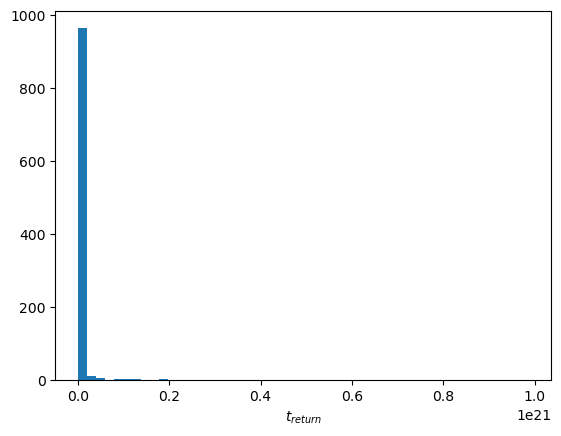

In [217]:
hist = plt.hist((t_events_3[(t_events_3>0.0) & (t_events_3<1e21)]),50)
plt.xlabel(r'$t_{return}$');

M_peak_3 = 2.142e-13 at time t_peak_3 = 8.067e+16


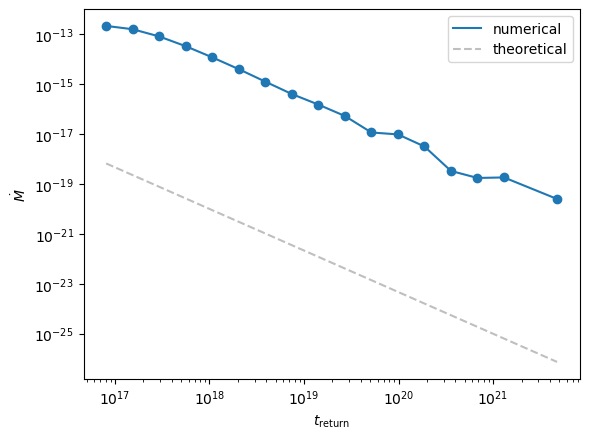

In [218]:
valid_t_events_3 = t_events_3[t_events_3 > 0.0]
num_bins = 20

min_t_plot = np.min(valid_t_events_3)
max_t_plot = np.max(valid_t_events_3)

log_bins = np.logspace(np.log10(min_t_plot), np.log10(max_t_plot), num_bins + 1)
counts, bin_edges = np.histogram(valid_t_events_3, bins=log_bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths = np.diff(bin_edges)

m_debris_particle = mstar / N

# only consider bins where counts are not zero
dm_dt_numerical = (counts * m_debris_particle) / bin_widths

valid_indices = dm_dt_numerical > 0
bin_centers_filtered_3 = bin_centers[valid_indices]
dm_dt_numerical_filtered_3 = dm_dt_numerical[valid_indices]


if len(dm_dt_numerical_filtered_3) > 0:
    peak_idx = np.argmax(dm_dt_numerical_filtered_3)
    t_peak_3 = bin_centers_filtered_3[peak_idx]
    M_peak_3 = dm_dt_numerical_filtered_3[peak_idx]
    print(f'M_peak_3 = %.3e at time t_peak_3 = %.3e' % (M_peak_3, t_peak_3) )

plt.plot(bin_centers_filtered_3, dm_dt_numerical_filtered_3,label='numerical')
plt.scatter(bin_centers_filtered_3, dm_dt_numerical_filtered_3)

plt.plot(bin_centers_filtered_3, 1e10 * bin_centers_filtered_3**(-5/3),linestyle='--',color='gray',alpha=0.5,label='theoretical')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{\text{return}}$')
plt.ylabel(r'$\dot{M}$')
plt.legend();

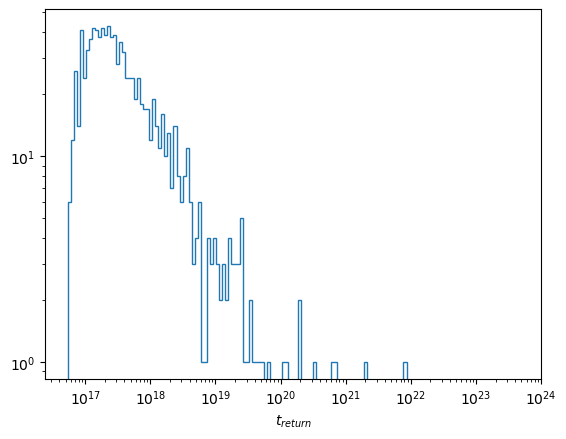

In [164]:
t_min_sim_3_2 = np.min(t_events_3_2)
t_max_sim_3_2 = np.max(t_events_3_2)

custom_bins_3_2 = np.logspace(np.log10(t_min_sim_3_2 * 0.99), np.log10(t_max_sim_3_2), 150)

plt.hist(t_events_3_2, bins=custom_bins_3_2, density=False, histtype='step')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{return}$');

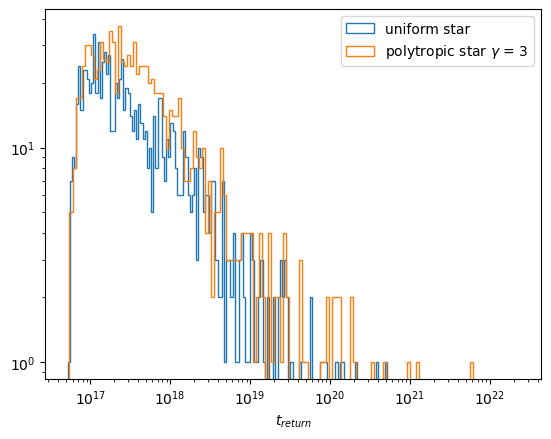

In [221]:
t_min_sim_3 = np.min(t_events_3)
t_max_sim_3 = np.max(t_events_3)

custom_bins_3 = np.logspace(np.log10(t_min_sim_3 * 0.99), np.log10(t_max_sim_3), 150)

plt.hist(t_events, bins=custom_bins, density=False, histtype='step', label='uniform star')
plt.hist(t_events_3, bins=custom_bins_3, density=False, histtype='step', label=r'polytropic star $\gamma$ = 3')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$t_{return}$')
plt.legend();

## PARAMETER SURVEY

## Over $\beta$

In [166]:
betas = np.linspace(1,5,10)
N = 2000
m_debris_particle = mstar / N

In [222]:
t_peaks_beta_3 = []
Mdot_peaks_beta_3 = []
eta=1

for beta_j in betas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta, delta_rs_3)
    t_peaks_beta_3.append(t_p_j)
    Mdot_peaks_beta_3.append(M_p_j)

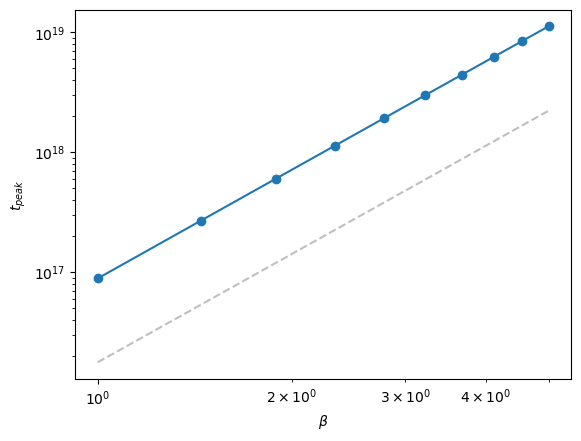

In [223]:
plt.scatter(betas, t_peaks_beta_3)
plt.plot(betas, t_peaks_beta_3)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta_3[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)

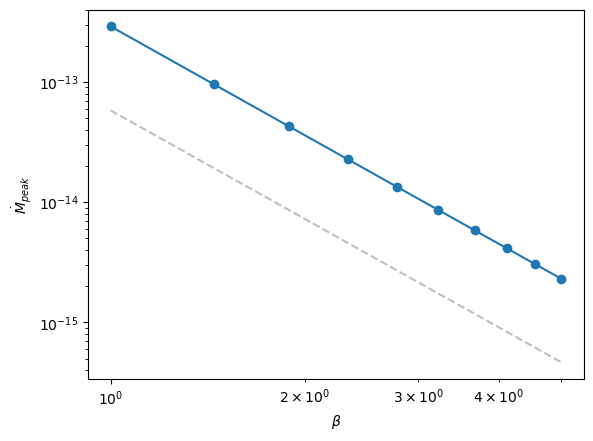

In [224]:
plt.scatter(betas, Mdot_peaks_beta_3)
plt.plot(betas, Mdot_peaks_beta_3)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta_3[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)

## Over $\eta$

In [170]:
etas = np.logspace(-1,2,10)
etas*M/mstar

array([1.00000000e+05, 2.15443469e+05, 4.64158883e+05, 1.00000000e+06,
       2.15443469e+06, 4.64158883e+06, 1.00000000e+07, 2.15443469e+07,
       4.64158883e+07, 1.00000000e+08])

In [225]:
t_peaks_eta_3 = []
Mdot_peaks_eta_3 = []
beta_j=betas[0]

for eta_j in etas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta_j, delta_rs_3)
    t_peaks_eta_3.append(t_p_j)
    Mdot_peaks_eta_3.append(M_p_j)

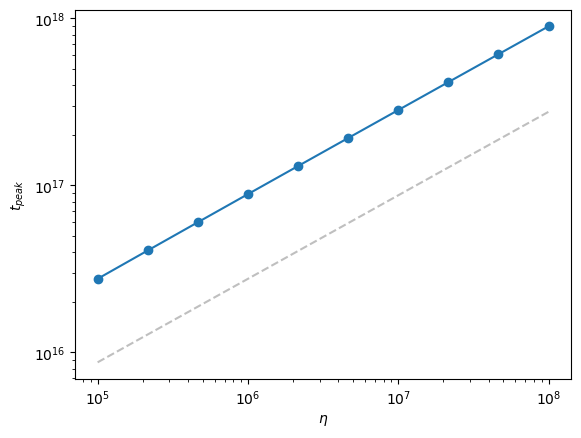

In [226]:
plt.scatter(etas*M/mstar, t_peaks_eta_3)
plt.plot(etas*M/mstar, t_peaks_eta_3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$') # here the true eta = M_bh/mstar
plt.ylabel(r'$t_{peak}$')
plt.plot(etas*M/mstar, t_peaks_eta_3[0]*etas**(0.5), linestyle='--', color='grey', alpha=0.5)

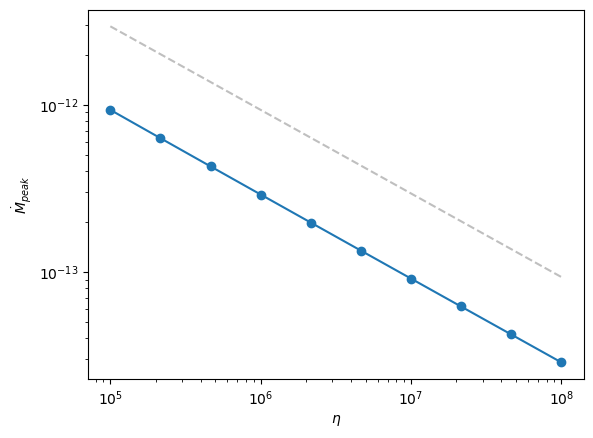

In [227]:
plt.scatter(etas*M/mstar, Mdot_peaks_eta_3)
plt.plot(etas*M/mstar, Mdot_peaks_eta_3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(etas*M/mstar, Mdot_peaks_eta_3[0]*etas**(-0.5), linestyle='--', color='grey', alpha=0.5)

# UNIFORM vs. POLYTROPIC COMPARISON

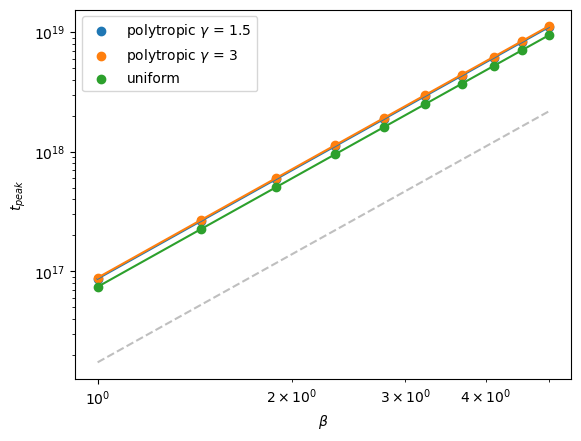

In [228]:
plt.scatter(betas, t_peaks_beta_3_2, label=r'polytropic $\gamma$ = 1.5')
plt.plot(betas, t_peaks_beta_3_2)
plt.scatter(betas, t_peaks_beta_3, label=r'polytropic $\gamma$ = 3')
plt.plot(betas, t_peaks_beta_3)
plt.scatter(betas, t_peaks_beta, label=r'uniform')
plt.plot(betas, t_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta_3_2[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)
plt.legend();

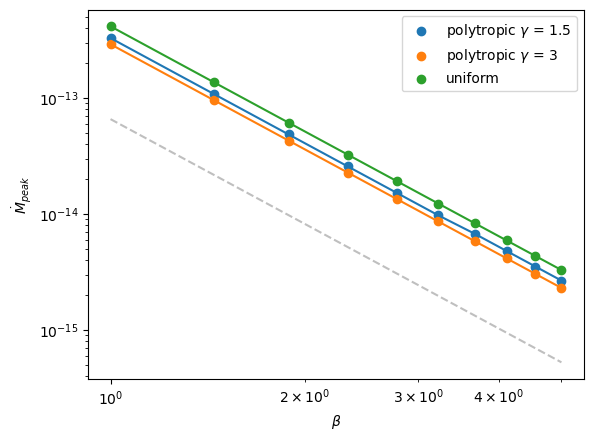

In [229]:
plt.scatter(betas,Mdot_peaks_beta_3_2, label=r'polytropic $\gamma$ = 1.5')
plt.plot(betas,Mdot_peaks_beta_3_2)
plt.scatter(betas,Mdot_peaks_beta_3, label=r'polytropic $\gamma$ = 3')
plt.plot(betas,Mdot_peaks_beta_3)
plt.scatter(betas,Mdot_peaks_beta, label=r'uniform')
plt.plot(betas,Mdot_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta_3_2[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)
plt.legend();

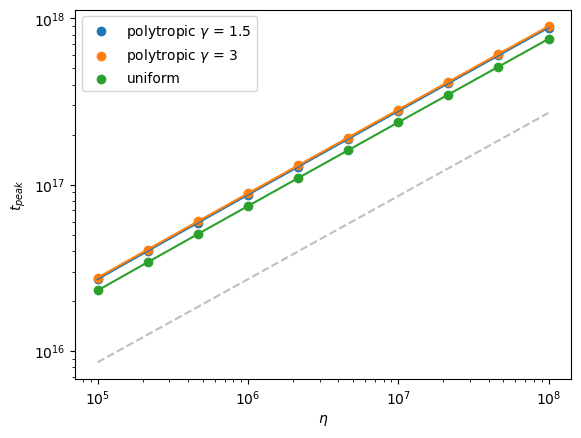

In [230]:
plt.scatter(etas*M/mstar, t_peaks_eta_3_2, label=r'polytropic $\gamma$ = 1.5')
plt.plot(etas*M/mstar, t_peaks_eta_3_2)
plt.scatter(etas*M/mstar, t_peaks_eta_3, label=r'polytropic $\gamma$ = 3')
plt.plot(etas*M/mstar, t_peaks_eta_3)
plt.scatter(etas*M/mstar, t_peaks_eta, label=r'uniform')
plt.plot(etas*M/mstar, t_peaks_eta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$') # here the true eta = M_bh/mstar
plt.ylabel(r'$t_{peak}$')
plt.plot(etas*M/mstar, t_peaks_eta_3_2[0]*etas**(0.5), linestyle='--', color='grey', alpha=0.5)
plt.legend();

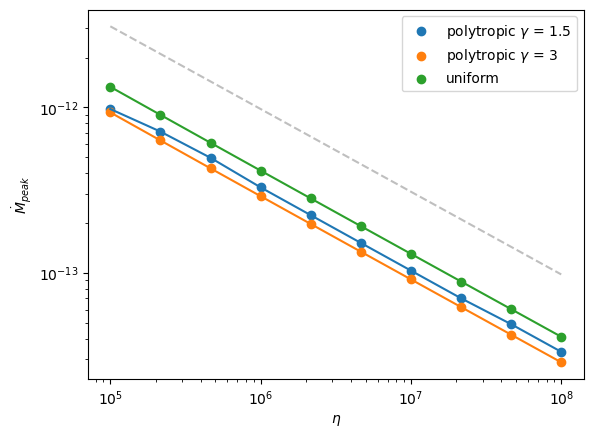

In [231]:
plt.scatter(etas*M/mstar, Mdot_peaks_eta_3_2, label=r'polytropic $\gamma$ = 1.5')
plt.plot(etas*M/mstar, Mdot_peaks_eta_3_2)
plt.scatter(etas*M/mstar, Mdot_peaks_eta_3, label=r'polytropic $\gamma$ = 3')
plt.plot(etas*M/mstar, Mdot_peaks_eta_3)
plt.scatter(etas*M/mstar, Mdot_peaks_eta, label=r'uniform')
plt.plot(etas*M/mstar, Mdot_peaks_eta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(etas*M/mstar, Mdot_peaks_eta_3_2[0]*etas**(-0.5), linestyle='--', color='grey', alpha=0.5)
plt.legend();

## Over $\beta$

In [ ]:
betas = np.linspace(1,5,10)
N = 2000
m_debris_particle = mstar / N

In [ ]:
def t_Mdot_peak(beta_j, eta_j, N=2000):
    RT = Rstar * (M  * eta_j/ mstar)**(1/3)
    M_current_bh = M * eta_j 

    r0_j = k * beta_j * RT
    v0_j = np.sqrt(2*G*(M_current_bh)/r0_j) 
    L_j = np.sqrt(2 * G * M_current_bh * beta_j * RT) 

    vy0_j = L_j / r0_j
    vx0_j = np.sqrt(v0_j**2 - vy0_j**2)

    y0_j = np.array([-r0_j, vx0_j, 0.0, vy0_j, 0.0, 0.0])

    t_span_j = [10, 2 * np.sqrt(r0_j**3 / (2*G*M_current_bh))] 
    sol_ic_j = solve_ivp(f_prime, t_span_j, y0_j, events=pericentre_event, max_step=1e15, rtol=1e-11, atol=1e-11, args=(M_current_bh,)) 

    y_p_j = sol_ic_j.y_events
    if len(y_p_j[0]) == 0:
        print(f"No initial pericentre event found for beta_j={beta_j}, eta_j={eta_j}")
        return np.nan, np.nan

    v_p_j = unpack(y_p_j[0][0])[1]
    R_p_j = unpack(y_p_j[0][0])[0]
    print(R_p_j)

    t_events_j = []
    y_events_j = []
    per_versor_j = R_p_j/np.linalg.norm(R_p_j)
    pericentre_event.terminal = False
    Es_j = np.linalg.norm(v_p_j)**2/2 - G*M_current_bh/(np.linalg.norm(R_p_j)+delta_rs)
    Es_bound_j = Es_j[Es_j<0]
    delta_rs_bound_j = delta_rs[Es_j<0]
    ts_kep_j = np.pi*G*M_current_bh/(2*abs(Es_bound_j))**1.5 
    print(len(Es_bound_j))


    for i in range(len(delta_rs_bound_j)):
        r0_j = (np.linalg.norm(R_p_j) + delta_rs_bound_j[i]) * per_versor_j
        y0_j = np.array([r0_j[0], v_p_j[0], r0_j[1], v_p_j[1], r0_j[2], v_p_j[2]])

        t_span_i = [0, 1.5 * ts_kep_j[i]]

        sol_j = solve_ivp(f_prime, t_span_i, y0_j, events=pericentre_event, rtol=1e-11, atol=1e-11, args=(M_current_bh,)) 

        if len(sol_j.t_events[0]) == 0:
            t_events_j.append(0.0)
        elif len(sol_j.t_events[0]) > 1: # More than one event found, take the second one
            t_events_j.append(sol_j.t_events[0][1])
        else: 
            if sol_j.t_events[0][0] > ts_kep_j[i]/100:
                t_events_j.append(sol_j.t_events[0][0])
            else: # One event found but too early, treat as no valid event
                t_events_j.append(0.0)
        #print(sol_j.t_events[0])
    t_events_j = np.array(t_events_j)
    #print(t_events_j)
    t_min_sim_j = np.min(t_events_j[t_events_j > 0.0]) if any(t > 0.0 for t in t_events_j) else 0.0 
    t_max_sim_j = np.max(t_events_j) 

    if t_max_sim_j == 0.0: # If all return times are 0, we can't create log bins
        return np.nan, np.nan

    custom_bins = np.logspace(np.log10(t_min_sim_j * 0.99), np.log10(t_max_sim_j), 150)

    #plt.hist(t_events_j, bins=custom_bins, density=False, histtype='step',label=r'$eta$='+str(beta_j))
    counts_j, bin_edges_j = np.histogram(t_events_j, bins=custom_bins)

    bin_centers_j = (bin_edges_j[:-1] + bin_edges_j[1:]) / 2
    bin_widths_j = np.diff(bin_edges_j)


    dm_dt_numerical_j = (counts_j * m_debris_particle) / bin_widths_j

    valid_indices_j = dm_dt_numerical_j > 0
    bin_centers_j_filtered = bin_centers_j[valid_indices_j]
    dm_dt_numerical_j_filtered = dm_dt_numerical_j[valid_indices_j]


    if len(dm_dt_numerical_j_filtered) > 0:
        peak_idx_j = np.argmax(dm_dt_numerical_j_filtered)
        t_peak_j = bin_centers_j_filtered[peak_idx_j]
        M_peak_j = dm_dt_numerical_j_filtered[peak_idx_j]
        print(f'M_peak = %.3e at time t_peak_j = %.3e' % (M_peak_j, t_peak_j) )

        return t_peak_j, M_peak_j
    else: return np.nan, np.nan

In [ ]:
t_peaks_beta = []
Mdot_peaks_beta = []
eta=1

for beta_j in betas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta)
    t_peaks_beta.append(t_p_j)
    Mdot_peaks_beta.append(M_p_j)

In [ ]:
plt.scatter(betas, t_peaks_beta)
plt.plot(betas, t_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)

In [ ]:
plt.scatter(betas, Mdot_peaks_beta)
plt.plot(betas, Mdot_peaks_beta)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)

## Over $\eta$

In [ ]:
etas = np.logspace(-1,2,10)
etas*M/mstar

In [ ]:
t_peaks_eta = []
Mdot_peaks_eta = []
beta_j=betas[0]

for eta_j in etas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta_j)
    t_peaks_eta.append(t_p_j)
    Mdot_peaks_eta.append(M_p_j)

In [ ]:
plt.scatter(etas*M/mstar, t_peaks_eta)
plt.plot(etas*M/mstar, t_peaks_eta)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$') # here the true eta = M_bh/mstar
plt.ylabel(r'$t_{peak}$')
plt.plot(etas*M/mstar, t_peaks_eta[0]*etas**(0.5), linestyle='--', color='grey', alpha=0.5)

In [ ]:
plt.scatter(etas*M/mstar, Mdot_peaks_eta)
plt.plot(etas*M/mstar, Mdot_peaks_eta)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(etas*M/mstar, Mdot_peaks_eta[0]*etas**(-0.5), linestyle='--', color='grey', alpha=0.5)

# CONVERGENCE TESTS

In [178]:
(ts_kep[ts_kep>1e19])

array([1.07783217e+19, 1.11908524e+19, 1.48852507e+20, 2.61041652e+21,
       6.10008619e+20, 7.80930697e+19, 1.39079768e+20, 8.53220522e+19,
       1.03932931e+19, 1.29902016e+19, 2.06416827e+19, 3.99620316e+20,
       1.22997928e+20, 2.98828388e+19, 1.39935703e+19, 2.71572581e+19,
       2.35984360e+19, 5.84956999e+19, 2.25564382e+19, 1.63937417e+19,
       2.39258190e+19, 2.78007477e+19, 2.15299339e+20, 2.81006276e+19,
       2.52144346e+19, 1.64442494e+19, 2.25342745e+19, 2.87194174e+19,
       2.01050750e+19, 5.80115879e+19, 4.93081845e+20, 1.45050816e+19,
       1.39739782e+19, 1.05627279e+19, 1.40155152e+19, 8.83660133e+19,
       2.45404538e+19, 2.52234545e+19, 1.30096140e+19, 1.09528903e+19,
       3.21714146e+19, 1.19091589e+19, 4.16180116e+19])

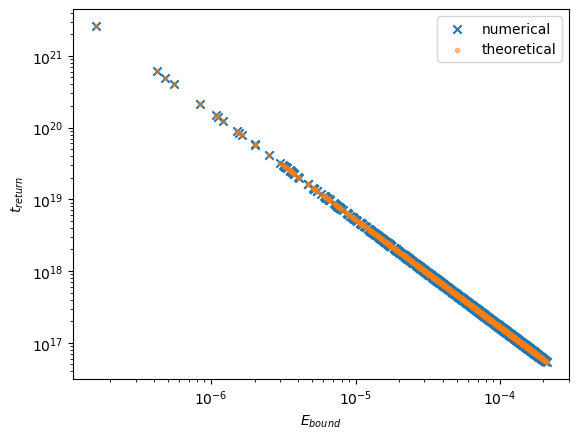

In [179]:
plt.scatter(abs(Es_bound),t_events,marker='x',alpha=1, label='numerical')
plt.scatter(abs(Es_bound),ts_kep,marker='.',alpha=0.5, label='theoretical')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel(r'$E_{bound}$')
plt.ylabel(r'$t_{return}$');

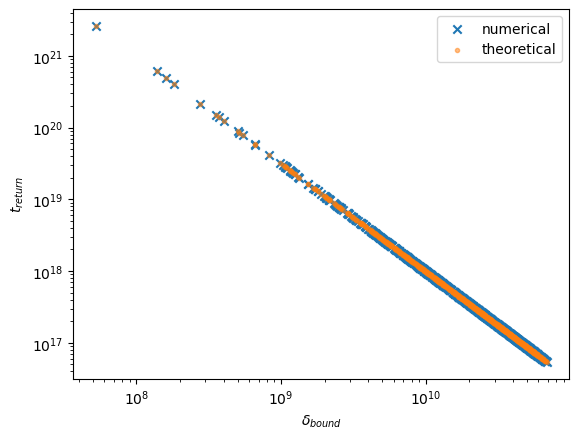

In [180]:
plt.scatter(abs(delta_rs_bound),np.array(t_events),marker='x',alpha=1, label='numerical')
plt.scatter(abs(delta_rs_bound),ts_kep,marker='.',alpha=0.5, label='theoretical')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel(r'$\delta_{bound}$')
plt.ylabel(r'$t_{return}$');

In [181]:
sort_Es = np.array(sorted(Es_bound))
sort_ts = sorted(t_events, reverse=True)
sort_kep_ts = sorted(ts_kep, reverse=True)

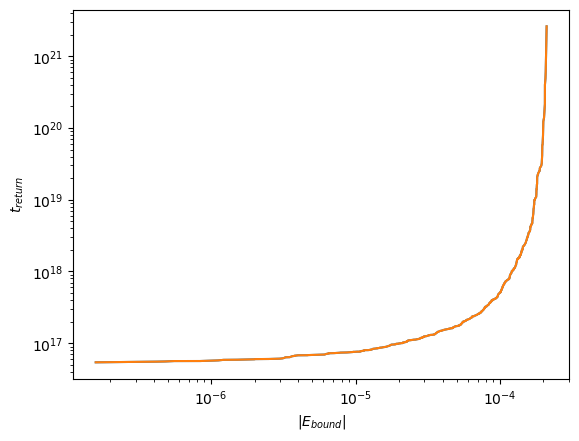

In [182]:
plt.plot(abs(sort_Es), sort_ts)
plt.plot(abs(sort_Es), sort_kep_ts)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$|E_{bound}|$')
plt.ylabel(r'$t_{return}$');

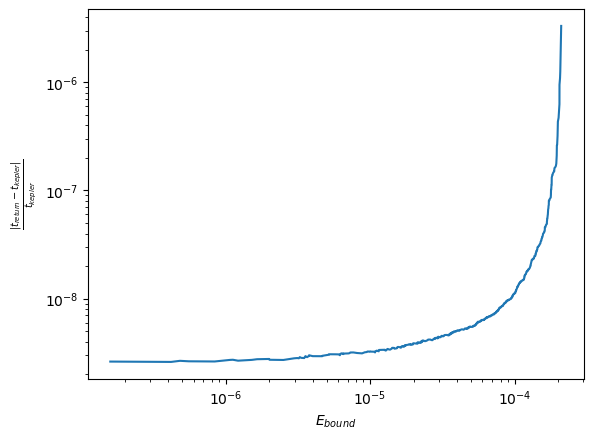

In [183]:
plt.plot(abs(sort_Es), abs(np.array(sort_kep_ts)-np.array(sort_ts))/sort_kep_ts)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E_{bound}$')
plt.ylabel(r'$\frac{|t_{return}-t_{kepler}|}{t_{kepler}}$');

# TOLERANCE DEPENDENCE

In [185]:
# let's take the last particle
tolerances = np.logspace(-13, -4, 15)

errors = []
energy_conservation_errors = []

for tol in tolerances:
    sol_test = solve_ivp(f_prime, t_span_i, y0_i,  events=pericentre_event, args=(M,),
                         rtol=tol, atol=tol, dense_output=True)

    t_num_test = np.nan
    if len(sol_test.t_events[0]) > 1:
        t_num_test = sol_test.t_events[0][1]
    elif len(sol_test.t_events[0]) == 1:
        t_num_test = sol_test.t_events[0][0]

    if not np.isnan(t_num_test):
        error = np.abs(t_num_test - ts_kep[-1]) / ts_kep[-1]
        errors.append(error)
    else:
        errors.append(np.nan)

    t_eval = np.linspace(t_span_i[0], sol_test.t[-1], 100)
    y_eval = sol_test.sol(t_eval)

    energies_along_orbit = []
    for j in range(len(t_eval)):
        r_j, v_j = unpack(y_eval[:, j])
        E_j = np.linalg.norm(v_j)**2/2 - G*M/np.linalg.norm(r_j)
        energies_along_orbit.append(E_j)

    max_energy_error = np.max(np.abs(np.array(energies_along_orbit) - Es_bound[-1])) / np.abs(Es_bound[-1])
    energy_conservation_errors.append(max_energy_error)

In [186]:
for i, tol in enumerate(tolerances):
    print('tolerance = %.3e,\t\terror = %.3e,\t error on energy conservation = %.3e' % (tol, errors[i], energy_conservation_errors[i]))

tolerance = 1.000e-13,		error = 1.078e-09,	 error on energy conservation = 7.215e-10
tolerance = 4.394e-13,		error = 1.144e-09,	 error on energy conservation = 7.657e-10
tolerance = 1.931e-12,		error = 1.483e-09,	 error on energy conservation = 1.035e-09
tolerance = 8.483e-12,		error = 3.263e-09,	 error on energy conservation = 2.291e-09
tolerance = 3.728e-11,		error = 1.320e-08,	 error on energy conservation = 9.204e-09
tolerance = 1.638e-10,		error = 6.664e-08,	 error on energy conservation = 4.754e-08
tolerance = 7.197e-10,		error = 3.539e-07,	 error on energy conservation = 2.476e-07
tolerance = 3.162e-09,		error = 1.528e-06,	 error on energy conservation = 1.044e-06
tolerance = 1.389e-08,		error = 7.498e-06,	 error on energy conservation = 5.101e-06
tolerance = 6.105e-08,		error = 3.666e-05,	 error on energy conservation = 2.495e-05
tolerance = 2.683e-07,		error = 1.712e-04,	 error on energy conservation = 1.173e-04
tolerance = 1.179e-06,		error = 7.282e-04,	 error on energy conse

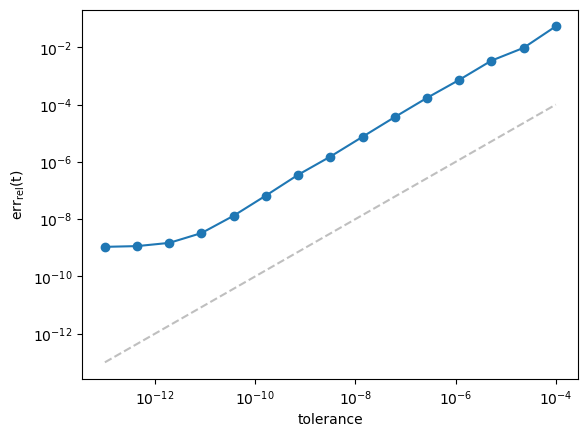

In [240]:
plt.scatter(tolerances,errors)
plt.plot(tolerances,errors)
plt.xlabel('tolerance')
plt.ylabel(r'$\rm{err}_{rel}(t)$')
plt.xscale('log')
plt.yscale('log')
x = np.linspace(min(tolerances),max(tolerances),1000)
plt.plot(x,x**1,color='grey',alpha=0.5,linestyle='--')

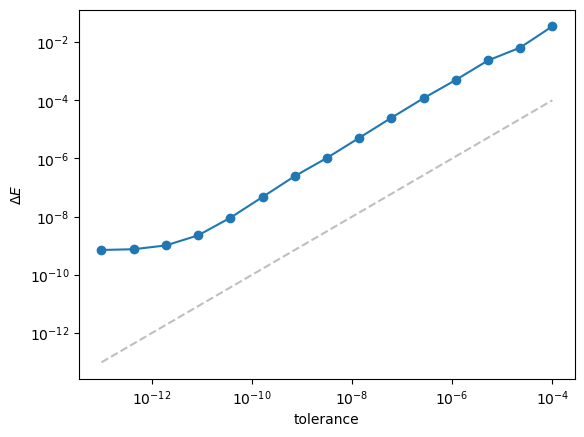

In [236]:
plt.scatter(tolerances,energy_conservation_errors)
plt.plot(tolerances,energy_conservation_errors)
plt.xlabel('tolerance')
plt.ylabel(r'$\Delta E$')
plt.xscale('log')
plt.yscale('log')
plt.plot(x,x**1,color='grey',alpha=0.5,linestyle='--')

# REQUESTS

Suggested Methodology: Adaptive ODE-IVP (RK45 or equivalent) with event detection for Steps 1 and 3; direct summation over $N \gtrsim 10^3$ debris particles; numerical differentiation or binning for $\dot{M}(t)$.

Suggested investigation:
<dl>
<dd> a. Convergence test (Newtonian). Set $\mathbf{a}_{\mathrm{PN}}=\mathbf{0}$. For a single debris particle with energy $E_i=-\delta E / 2$, compare the numerically integrated return time $t_i^{\text {num }}$ with the analytical value $t_i^{\text {Kep }}$ from equation (23) as a function of the integrator tolerance $\varepsilon$. Show that the error $\left|t_i^{\text {num }}-t_i^{\text {Kep }}\right| / t_i^{\text {Kep }}$ decreases with $\varepsilon$ at the expected order of the scheme. Also verify that energy is conserved along the orbit to the same level as $\varepsilon$. </dd>

    
<dd> b. Orbital trajectory. Plot $\mathbf{r}(t)$ for the stellar centre of mass (Newtonian), marking $R_T$ and $r_p$. Confirm that the orbit is parabolic by verifying $E_{\mathrm{cm}}=0$ to numerical precision throughout the integration.</dd>


<dd> c. Tidal force. Plot the tidal force $F_{\text {tidal }}(t)=2 G M_{\bullet} R_{\star} / r^3$ along the orbit. At what time does it peak, and how does the peak value scale with $\beta$?</dd>


<dd> d. Energy distribution. Plot $d M / d E$ for the debris. Show that it is uniform (as expected for a constant-density star) and that the half-width $\delta E$ scales as predicted by equation (22).</dd>


<dd> e. Fallback rate (Newtonian). Using equation (23) for the return times, construct $\dot{M}(t)$ and plot it on a $\log -\log$ scale. Verify the $t^{-5 / 3}$ power law at late times and identify the peak fallback rate $\dot{M}_{\text {peak }}$ and the time to peak $t_{\text {peak }}$. </dd>


<dd> f. Relativistic corrections. Repeat Step 3 with the 1PN correction (21) active. On the same axes, compare $\dot{M}^{\mathrm{PN}}(t)$ with the Newtonian result. How do $\dot{M}_{\text {peak }}$ and $t_{\text {peak }}$ change? For which values of $M_{\bullet}$ and $\beta$ is the correction most significant? </dd>


<dd> g. (Extension) Parameter survey. Vary $\beta \in[1,5]$ and $M_{\bullet} / m_{\star} \in\left[10^5, 10^8\right]$. Characterise the scaling of $\dot{M}_{\text {peak }}$ and $t_{\text {peak }}$ with these parameters and compare with the analytical expectations $\dot{M}_{\text {peak }} \propto M_{\bullet}^{-1 / 2}$ and $t_{\text {peak }} \propto M_{\bullet}^{1 / 2}$. </dd>


<dd> h. (Extension) Non-uniform density profile. Replace the uniform sampling in Step 2 with a weighting proportional to a polytropic density profile $\rho(\delta r) \propto(1-$ $\left.\delta r^2 / R_{\star}^2\right)^n$ for $n=3 / 2$ and $n=3$. How does the shape of $d M / d E$ change, and what is the effect on the early-time behaviour of $\dot{M}(t)$? </dd>
</dl>

# 1PN

In [241]:
# INITIAL CONDITIONS
k = 1000
r0 = k * r_p
v0 = np.sqrt(2 * G * M / r0)
L_newt = np.sqrt(2 * G * M * r_p)
vy0_newt = L_newt / r0
vx0_newt = np.sqrt(v0**2 - vy0_newt**2)

In [242]:
def f_prime(t, y, M_bh_current, correction):
    r, rdot = unpack(y)
    r_magn = np.linalg.norm(r)
    v_magn = np.linalg.norm(rdot)

    GM_r3 = G * M_bh_current / (r_magn**3)
    if correction == '0PN': 
        aPN = np.zeros(3)
    elif correction == '1PN': 
        aPN = (GM_r3 / (c**2)) * ((4.0 * G * M_bh_current / r_magn - v_magn**2) * r + 4.0 * np.dot(r, rdot) * rdot)
    else:
        raise ValueError("Not implemented")
    
    rdd = - GM_r3 * r + aPN
    return [rdot[0], rdd[0], rdot[1], rdd[1], rdot[2], rdd[2]]

def get_energy_0PN(r_vec, v_vec, M_bh):
    r = np.linalg.norm(r_vec)
    v2 = np.dot(v_vec, v_vec)
    return 0.5 * v2 - (G * M_bh / r)

def get_energy_1PN(r_vec, v_vec, M_bh):
    r = np.linalg.norm(r_vec)
    v2 = np.dot(v_vec, v_vec)
    E_0PN = 0.5 * v2 - (G * M_bh / r)
    E_1PN_corr = (1.0 / c**2) * (0.375 * (v2**2) + 1.5 * (G * M_bh / r) * v2 + 0.5 * ((G * M_bh / r)**2))
    return E_0PN + E_1PN_corr

In [244]:
def pericentre_event_masked(t, y, M_bh_current, correction):
    r, rdot = unpack(y)
    r_magn = np.linalg.norm(r)
    r_dot = np.dot(r, rdot) / r_magn
    
    # Recupera il t_mask specifico per questa particella (predefinito a 1e5 se non impostato)
    t_mask = getattr(pericentre_event_masked, 't_mask', 1e5)
    
    # Bypassa i primissimi passi temporali per evitare il blocco a t=0
    if t < t_mask:
        return -1.0
        
    return r_dot
pericentre_event_masked.direction = 1  
pericentre_event_masked.terminal = True

In [245]:
t_ff = np.sqrt(r0**3 / (2 * G * M))
t_span = [0, 2.5 * t_ff]

y0_newt = np.array([-r0, vx0_newt, 0.0, vy0_newt, 0.0, 0.0])
pericentre_event_masked.t_mask = 1e5 # Maschera standard per il CM lontano
sol_cm_newt = solve_ivp(f_prime, t_span, y0_newt, events=pericentre_event_masked, 
                        args=(M, '0PN'), rtol=1e-11, atol=1e-11)
v_p_newt = unpack(sol_cm_newt.y_events[0][0])[1]
R_p_newt = unpack(sol_cm_newt.y_events[0][0])[0]

sol_cm_1pn = solve_ivp(f_prime, t_span, y0_newt, events=pericentre_event_masked, 
                       args=(M, '1PN'), rtol=1e-11, atol=1e-11)
v_p_1pn = unpack(sol_cm_1pn.y_events[0][0])[1]
R_p_1pn = unpack(sol_cm_1pn.y_events[0][0])[0]

In [246]:
N = 2000
np.random.seed(42)
delta_rs = np.random.uniform(-Rstar, Rstar, N)

In [247]:
t_returns_newt = []
t_returns_1pn = []

per_versor_newt = R_p_newt / np.linalg.norm(R_p_newt)
per_versor_1pn = R_p_1pn / np.linalg.norm(R_p_1pn)


for i in range(N):
    dr = delta_rs[i]
    
    # 0pn
    r0_particle_newt = (np.linalg.norm(R_p_newt) + dr) * per_versor_newt
    y0_part_newt = np.array([r0_particle_newt[0], v_p_newt[0], r0_particle_newt[1], v_p_newt[1], r0_particle_newt[2], v_p_newt[2]])
    E_part_newt = get_energy_0PN(r0_particle_newt, v_p_newt, M)
    
    if E_part_newt < 0: # Solo particelle legate
        t_kep_est = np.pi * G * M / (2 * abs(E_part_newt))**1.5
        # Iniettiamo la maschera temporale specifica nell'attributo della funzione evento
        pericentre_event_masked.t_mask = t_kep_est * 0.02
        
        sol_part_newt = solve_ivp(f_prime, [0, 2.5 * t_kep_est], y0_part_newt, events=pericentre_event_masked, args=(M, '0PN'), rtol=1e-10, atol=1e-10)
        if len(sol_part_newt.t_events[0]) > 0:
            t_returns_newt.append(sol_part_newt.t_events[0][0])
            
    # 1pn
    r0_particle_1pn = (np.linalg.norm(R_p_1pn) + dr) * per_versor_1pn
    y0_part_1pn = np.array([r0_particle_1pn[0], v_p_1pn[0], r0_particle_1pn[1], v_p_1pn[1], r0_particle_1pn[2], v_p_1pn[2]])
    E_part_1pn = get_energy_1PN(r0_particle_1pn, v_p_1pn, M)
    
    if E_part_1pn < 0: # Solo particelle legate nel regime 1PN
        t_kep_est_1pn = np.pi * G * M / (2 * abs(E_part_1pn))**1.5
        pericentre_event_masked.t_mask = t_kep_est_1pn * 0.02
        
        sol_part_1pn = solve_ivp(f_prime, [0, 2.5 * t_kep_est_1pn], y0_part_1pn, events=pericentre_event_masked, args=(M, '1PN'), rtol=1e-10, atol=1e-10)
        if len(sol_part_1pn.t_events[0]) > 0:
            t_returns_1pn.append(sol_part_1pn.t_events[0][0])

In [248]:
t_returns_newt = np.array(t_returns_newt)
t_returns_1pn = np.array(t_returns_1pn)
m_debris_particle = mstar / N

min_t = min(np.min(t_returns_newt), np.min(t_returns_1pn))
max_t = max(np.max(t_returns_newt), np.max(t_returns_1pn))
log_bins = np.logspace(np.log10(min_t * 0.95), np.log10(max_t * 1.05), 40)

counts_n, edges_n = np.histogram(t_returns_newt, bins=log_bins)
#plt.hist(t_returns_newt, bins=log_bins)
bin_centers_n = (edges_n[:-1] + edges_n[1:]) / 2
widths_n = np.diff(edges_n)
dM_dt_n = (counts_n * m_debris_particle) / widths_n

counts_1pn, edges_1pn = np.histogram(t_returns_1pn, bins=log_bins)
#plt.hist(t_returns_1pn, bins=log_bins)

bin_centers_1pn = (edges_1pn[:-1] + edges_1pn[1:]) / 2
widths_1pn = np.diff(edges_1pn)
dM_dt_1pn = (counts_1pn * m_debris_particle) / widths_1pn

valid_n = dM_dt_n > 0
valid_1pn = dM_dt_1pn > 0

idx_peak_n = np.argmax(dM_dt_n)
idx_peak_1pn = np.argmax(dM_dt_1pn)
print(f"newtonian: t_peak = {bin_centers_n[idx_peak_n]:.3e}, Mdot_peak = {dM_dt_n[idx_peak_n]:.3e}")
print(f"1PN: t_peak = {bin_centers_1pn[idx_peak_1pn]:.3e}, Mdot_peak = {dM_dt_1pn[idx_peak_1pn]:.3e}")

newtonian: t_peak = 1.313e+15, Mdot_peak = 3.111e-11
1PN: t_peak = 4.608e+14, Mdot_peak = 1.735e-10


In [258]:
def t_Mdot_peak(beta_j, eta_j, delta_rs_profile):
    M_current_bh = M * eta_j
    RT_current = Rstar * (M_current_bh / mstar)**(1/3)
    r0_j = k * beta_j * RT_current

    v0_j = np.sqrt(2*G*M_current_bh/r0_j)
    L_j = np.sqrt(2 * G * M_current_bh * beta_j * RT_current)

    vy0_j = L_j / r0_j
    vx0_j = np.sqrt(v0_j**2 - vy0_j**2)
    y0_j = np.array([-r0_j, vx0_j, 0.0, vy0_j, 0.0, 0.0])

    t_span_j = [0, 2 * np.sqrt(r0_j**3 / (2*G*M_current_bh))] 
    sol_ic_j = solve_ivp(f_prime, t_span_j, y0_j, events=pericentre_event_masked, rtol=1e-11, atol=1e-11, args=(M_current_bh,'1PN',)) 

    if len(sol_ic_j.y_events[0]) == 0:
        return np.nan, np.nan

    v_p_j = unpack(sol_ic_j.y_events[0][0])[1]
    R_p_j = unpack(sol_ic_j.y_events[0][0])[0]

    t_returns_1pn = []
    per_versor_j = R_p_j / np.linalg.norm(R_p_j)
    pericentre_event_masked.terminal = False
    
    Es_j = np.linalg.norm(v_p_j)**2/2 - G*M_current_bh/(np.linalg.norm(R_p_j) + delta_rs_profile)
    
    Es_bound_j = Es_j[Es_j < 0]
    delta_rs_bound_j = delta_rs_profile[Es_j < 0]
    ts_kep_j = np.pi * G * M_current_bh / (2 * abs(Es_bound_j))**1.5 

    # Iterate only over bound particles
    for i in range(len(delta_rs_bound_j)): 
        dr = delta_rs_bound_j[i] 
        
        # 1pn calculation for debris particle return times
        r0_particle_1pn = (np.linalg.norm(R_p_j) + dr) * per_versor_j
        y0_part_1pn = np.array([r0_particle_1pn[0], v_p_j[0], r0_particle_1pn[1], v_p_j[1], r0_particle_1pn[2], v_p_j[2]])
        
        t_kep_est_1pn_for_particle = ts_kep_j[i]

        pericentre_event_masked.t_mask = t_kep_est_1pn_for_particle * 0.02
            
        sol_part_1pn = solve_ivp(f_prime, [0, 2.5 * t_kep_est_1pn_for_particle], y0_part_1pn, events=pericentre_event_masked, args=(M_current_bh, '1PN'), rtol=1e-11, atol=1e-11)
        if len(sol_part_1pn.t_events[0]) > 0:
            t_returns_1pn.append(sol_part_1pn.t_events[0][0])
        else:
            t_returns_1pn.append(0.0) # Append 0.0 if no event found for this particle
                    
    t_returns_1pn = np.array(t_returns_1pn)
    valid_t = t_returns_1pn[t_returns_1pn > 0.0]
    if len(valid_t) == 0: return np.nan, np.nan

    custom_bins = np.logspace(np.log10(np.min(valid_t) * 0.99), np.log10(np.max(valid_t)), 150)
    counts_j, bin_edges_j = np.histogram(t_returns_1pn, bins=custom_bins)

    bin_centers_j = (bin_edges_j[:-1] + bin_edges_j[1:]) / 2
    bin_widths_j = np.diff(bin_edges_j)

    # the mass is updated according to the profile
    m_particle_dyn = mstar / len(delta_rs_profile)
    dm_dt_numerical_j = (counts_j * m_particle_dyn) / bin_widths_j

    valid_indices_j = dm_dt_numerical_j > 0
    if not np.any(valid_indices_j): return np.nan, np.nan
    
    bin_centers_j_filtered = bin_centers_j[valid_indices_j]
    dm_dt_numerical_j_filtered = dm_dt_numerical_j[valid_indices_j]

    peak_idx_j = np.argmax(dm_dt_numerical_j_filtered) 

    print(f'M_peak = %.3e at time t_peak_j = %.3e' % (dm_dt_numerical_j_filtered[peak_idx_j], bin_centers_j_filtered[peak_idx_j]) )

    return bin_centers_j_filtered[peak_idx_j], dm_dt_numerical_j_filtered[peak_idx_j]

# UNIFORM STAR

## PARAMETER SURVEY

### Over $\beta$

In [259]:
betas = np.linspace(1,5,10)
N = 2000
m_debris_particle = mstar / N

In [260]:
t_peaks_beta_1pn = []
Mdot_peaks_beta_1pn = []
eta=1

for beta_j in betas:
    t_p_j, M_p_j = t_Mdot_peak(beta_j,eta, delta_rs)
    t_peaks_beta_1pn.append(t_p_j)
    Mdot_peaks_beta_1pn.append(M_p_j)

M_peak = 3.468e-08 at time t_peak_j = 2.414e+13
M_peak = 1.144e-08 at time t_peak_j = 7.739e+13
M_peak = 4.915e-09 at time t_peak_j = 1.738e+14
M_peak = 2.583e-09 at time t_peak_j = 3.323e+14
M_peak = 1.521e-09 at time t_peak_j = 5.659e+14
M_peak = 9.698e-10 at time t_peak_j = 8.893e+14
M_peak = 6.558e-10 at time t_peak_j = 1.317e+15
M_peak = 4.640e-10 at time t_peak_j = 1.864e+15
M_peak = 3.403e-10 at time t_peak_j = 2.544e+15
M_peak = 2.569e-10 at time t_peak_j = 3.373e+15


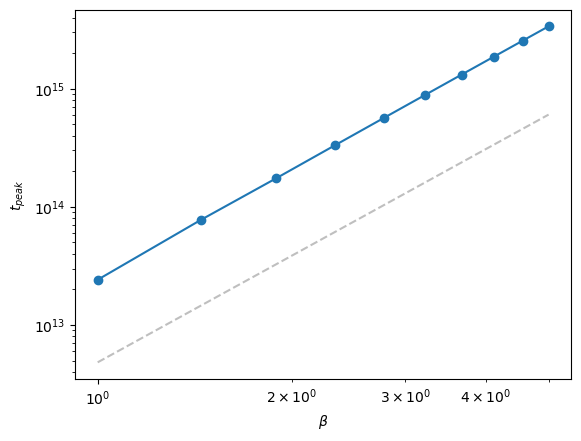

In [268]:
plt.scatter(betas, t_peaks_beta_1pn)
plt.plot(betas, t_peaks_beta_1pn)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$t_{peak}$')
plt.plot(betas, t_peaks_beta_1pn[0]/5*betas**3, linestyle='--', color='grey', alpha=0.5)

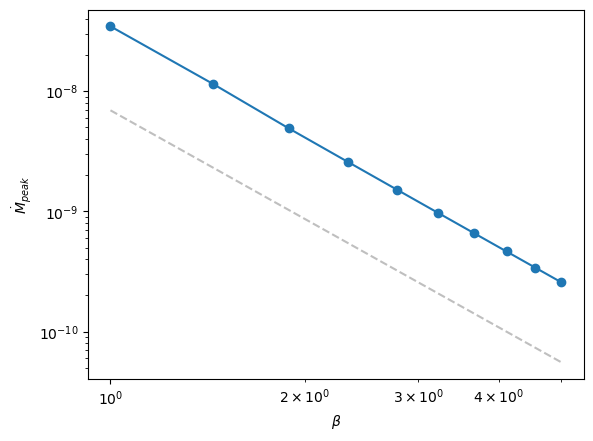

In [269]:
plt.scatter(betas, Mdot_peaks_beta_1pn)
plt.plot(betas, Mdot_peaks_beta_1pn)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\dot M_{peak}$')
plt.plot(betas, Mdot_peaks_beta_1pn[0]/5*betas**(-3), linestyle='--', color='grey', alpha=0.5)